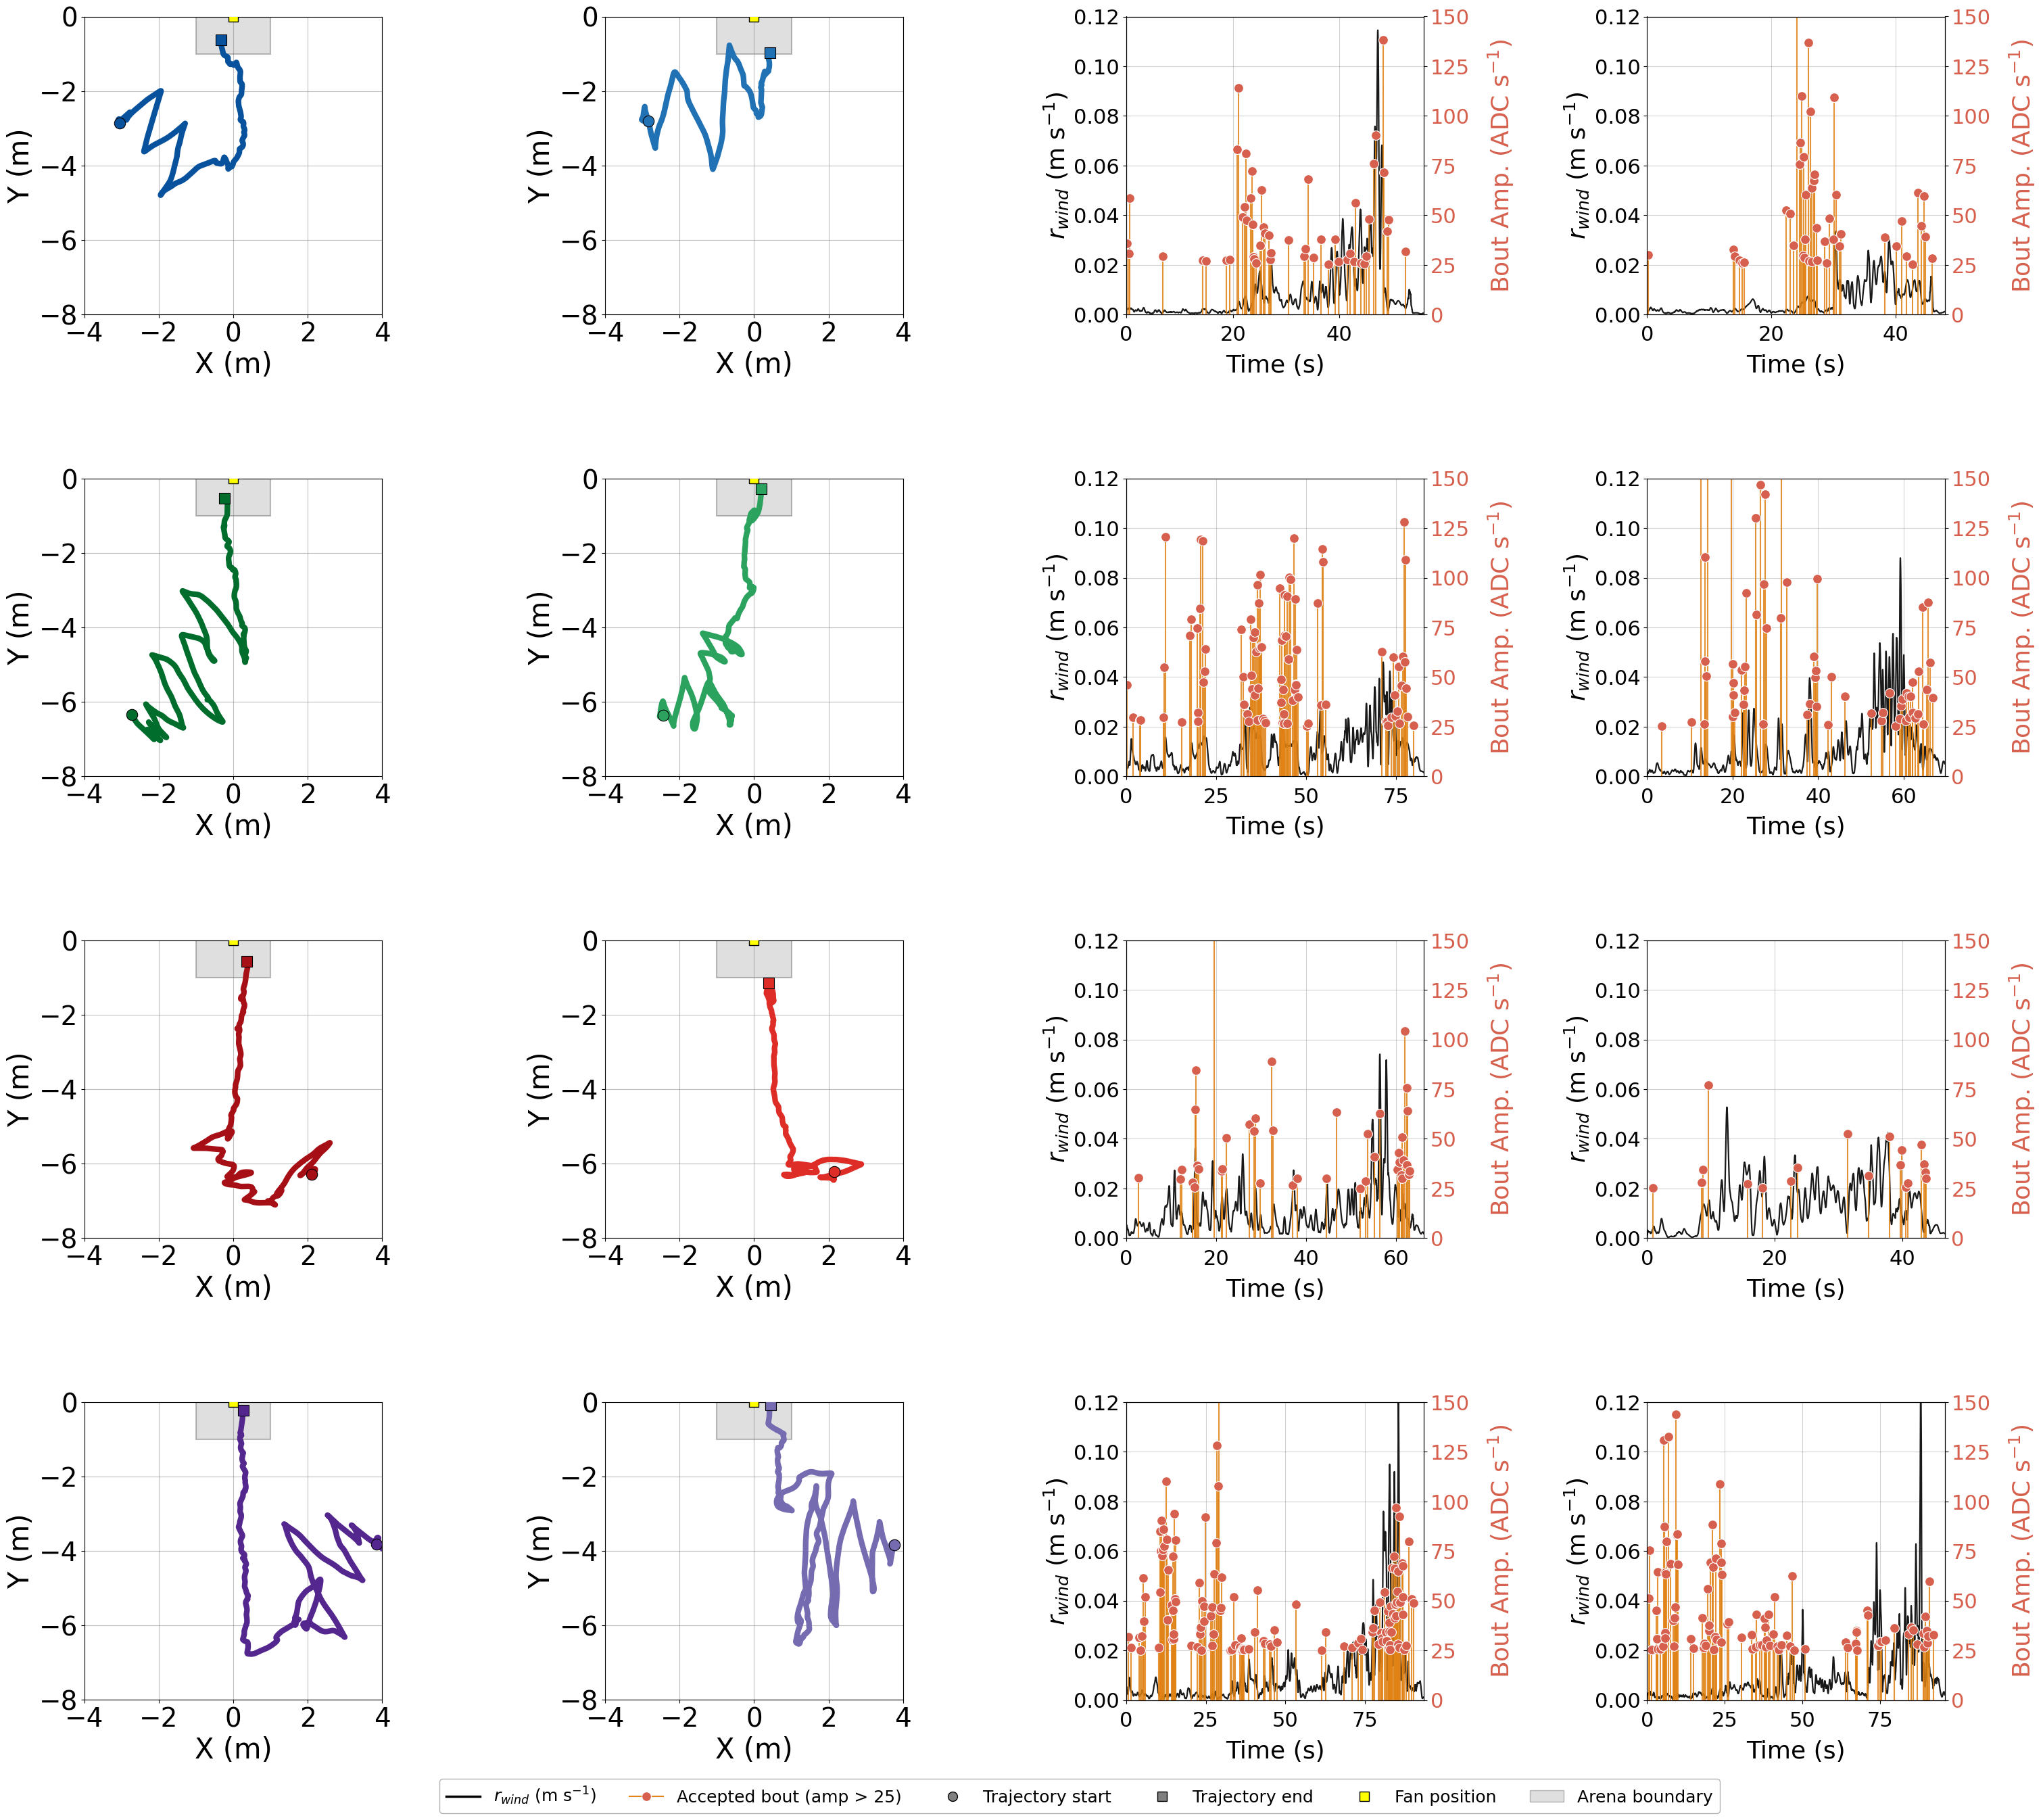

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from pathlib import Path
import re

plt.style.use('default')

# ── Trajectory (OptiTrack) files ──────────────────────────────────────────────
TRAJECTORY_FILES = r"""
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc1_Down.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc1_Ortho_2_perfect.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc2_Ortho_4.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc2_UpRedo_run3.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc3_Ortho_2.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc3_Up.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc4_Ortho.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Loc4_Down.csv
"""

# ── Log files ─────────────────────────────────────────────────────────────────
LOG_FILES = {
    'Loc1': {
        'non_ortho': r"C:\Users\ltjth\Documents\Research\UKF_Data\Good Runs\ARR_NC_Loc1_Down1.csv",
        'ortho':     r"C:\Users\ltjth\Documents\Research\UKF_Data\Good Runs\ARR_NC_Loc1_Ortho2_perfect.csv",
    },
    'Loc2': {
        'non_ortho': r"C:\Users\ltjth\Documents\Research\UKF_Data\Good Runs\ARR_NC_Loc2_UpRedo3.csv",
        'ortho':     r"C:\Users\ltjth\Documents\Research\UKF_Data\Good Runs\ARR_NC_Loc2_Ortho4.csv",
    },
    'Loc3': {
        'non_ortho': r"C:\Users\ltjth\Documents\Research\UKF_Data\Good Runs\ARR_NC_Loc3_Up1.csv",
        'ortho':     r"C:\Users\ltjth\Documents\Research\UKF_Data\Good Runs\ARR_NC_Loc3_Ortho2.csv",
    },
    'Loc4': {
        'non_ortho': r"C:\Users\ltjth\Documents\Research\UKF_Data\Good Runs\ARR_NC_Loc4_Down1.csv",
        'ortho':     r"C:\Users\ltjth\Documents\Research\UKF_Data\Good Runs\ARR_NC_Loc4_Ortho1.csv",
    },
}

# ── Column names ──────────────────────────────────────────────────────────────
COL_TIME     = 'Time'      # microseconds
COL_WIND     = 'Wind'      # m/s (already magnitude)
COL_BOUT_AMP = 'BoutAmp'   # bout amplitude from EWMA detector

BOUT_THRESHOLD = 25        # only accepted bouts above this value are shown

# ── Shared y-axis limits — adjust to fit your full dataset ───────────────────
WIND_YLIM = (0, 0.12)   # m/s
BOUT_YLIM = (0, 150)    # amplitude units

# ── Constants ─────────────────────────────────────────────────────────────────
FAN_X_RAW = -1514.199707 / 1000
FAN_Y_RAW =  2919.908203 / 1000

LOC_PALETTES = {
    'Loc1': ['#08519c', '#2171b5'],
    'Loc2': ['#006d2c', '#2ca25f'],
    'Loc3': ['#a50f15', '#de2d26'],
    'Loc4': ['#54278f', '#756bb1'],
}
DEFAULT_PALETTE = ['#636363', '#969696']

WIND_COLOR = 'black'
# ── Bout colours matching the bout explainer script ───────────────────────────
C_BOUT    = '#D6604D'   # marker fill
C_VLINE_S = '#E08214'   # stem line colour

FONT_TRAJ = 30
FONT_TS   = 26
TICK_TRAJ = 28
TICK_TS   = 22


# ── Helpers ───────────────────────────────────────────────────────────────────

def get_color(loc_key, run_type):
    palette = LOC_PALETTES.get(loc_key, DEFAULT_PALETTE)
    return palette[0] if run_type == 'non_ortho' else palette[1]


def find_cfmrl_position_cols(filepath):
    with open(filepath) as f:
        lines = f.readlines()
    type_line  = lines[2].strip().split(',')
    name_line  = lines[3].strip().split(',')
    attr_line  = lines[5].strip().split(',')
    coord_line = lines[6].strip().split(',')
    x_col = y_col = None
    for i, (t, n, a, c) in enumerate(zip(type_line, name_line, attr_line, coord_line)):
        if n.strip() == 'CFMRL' and t.strip() == 'Rigid Body' and a.strip() == 'Position':
            if c.strip() == 'X': x_col = i
            elif c.strip() == 'Y': y_col = i
    return x_col, y_col


def load_log(path):
    try:
        df = pd.read_csv(path, low_memory=False)
        df.columns = df.columns.str.strip()
        return df
    except Exception as e:
        print(f"  [warn] Could not load {path}: {e}")
        return None


def extract_trajectory_data(traj_path):
    """Extract x, y coordinates from trajectory file"""
    try:
        x_col, y_col = find_cfmrl_position_cols(traj_path)
        df = pd.read_csv(traj_path, skiprows=6, header=0, low_memory=False)
        x = pd.to_numeric(df.iloc[:, x_col], errors='coerce')
        y = pd.to_numeric(df.iloc[:, y_col], errors='coerce')
        mask = x.notna() & y.notna()
        x = x[mask].values - FAN_X_RAW
        y = y[mask].values - FAN_Y_RAW
        return x, y
    except Exception as e:
        print(f"  [warn] Could not extract trajectory data from {traj_path}: {e}")
        return None, None


def plot_trajectory(ax, traj_entry, loc_key, run_type):
    ax.set_facecolor('white')
    rect = plt.Rectangle((-1, -1.0), 2, 1.5,
                         linewidth=1.5, edgecolor='black',
                         facecolor='gray', alpha=0.25)
    ax.add_patch(rect)

    if traj_entry is not None:
        label, path = traj_entry
        color = get_color(loc_key, run_type)
        x, y = extract_trajectory_data(path)

        if x is not None and y is not None:
            ax.plot(x, y, color=color, linewidth=6, zorder=4)
            ax.scatter(x[0],  y[0],  color=color, marker='o', s=140,
                       zorder=5, edgecolors='black', linewidths=0.8)
            ax.scatter(x[-1], y[-1], color=color, marker='s', s=140,
                       zorder=5, edgecolors='black', linewidths=0.8)

    ax.scatter([], [], color='gray', marker='o', s=60,
               edgecolors='black', linewidths=0.8, label='Start')
    ax.scatter([], [], color='gray', marker='s', s=120,
               edgecolors='black', linewidths=0.8, label='End')
    ax.scatter(0, 0, color='yellow', marker='s', s=100,
               zorder=6, edgecolors='black', linewidths=1.0, label='Fan')

    ax.set_xlim(-4, 4)
    ax.set_ylim(-8, 0)
    ax.set_xlabel('X (m)', fontsize=FONT_TRAJ)
    ax.set_ylabel('Y (m)', fontsize=FONT_TRAJ)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.5, color='gray')
    ax.tick_params(labelsize=TICK_TRAJ)


def plot_timeseries(ax_w, log_path, loc_key, run_type):
    """
    Left axis  (ax_w): wind magnitude — black line, shared y-limits
    Right axis (ax_b): accepted bout amplitudes as stems matching explainer style
    """
    ax_b = ax_w.twinx()
    ax_w.set_facecolor('white')

    df = load_log(log_path)
    if df is None:
        return ax_b

    # Time in seconds, zero-referenced
    t = pd.to_numeric(df[COL_TIME], errors='coerce').values
    t = (t - t[0]) * 1e-6   # µs → s

    # ── Wind ─────────────────────────────────────────────────────────────────
    if COL_WIND in df.columns:
        wind = pd.to_numeric(df[COL_WIND], errors='coerce').values
        ax_w.plot(t, wind, color=WIND_COLOR, linewidth=1.6, alpha=0.9, zorder=3)
        ax_w.set_ylabel(r'$r_{wind}$ (m s$^{-1}$)', color=WIND_COLOR, fontsize=FONT_TS)
        ax_w.tick_params(axis='y', labelcolor=WIND_COLOR, labelsize=TICK_TS)
        ax_w.set_ylim(WIND_YLIM)
        ax_w.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    else:
        print(f"  [warn] Column '{COL_WIND}' not found in {log_path}")

    # ── Accepted bouts — stems matching explainer style ───────────────────────
    if COL_BOUT_AMP in df.columns:
        bout = pd.to_numeric(df[COL_BOUT_AMP], errors='coerce').values

        accepted = bout > BOUT_THRESHOLD
        changes  = np.diff(accepted.astype(int), prepend=0, append=0)
        starts   = np.where(changes ==  1)[0]
        ends     = np.where(changes == -1)[0]

        if len(starts) > 0:
            bout_t   = np.array([t[s] for s in starts])
            bout_amp = np.array([np.max(bout[s:e]) for s, e in zip(starts, ends)])

            markerline, stemlines, baseline = ax_b.stem(
                bout_t, bout_amp, markerfmt='o', basefmt=' ')
            plt.setp(stemlines,   color=C_VLINE_S, linewidth=1.5, alpha=0.85)
            markerline.set_markerfacecolor(C_BOUT)
            markerline.set_markeredgecolor('white')
            markerline.set_markeredgewidth(0.8)
            markerline.set_markersize(10)

        ax_b.set_ylabel(r'Bout Amp. (ADC s$^{-1}$)',
                        color=C_BOUT, fontsize=FONT_TS, labelpad=18)
        ax_b.tick_params(axis='y', labelcolor=C_BOUT, labelsize=TICK_TS)
        ax_b.set_ylim(BOUT_YLIM)
    else:
        print(f"  [warn] Column '{COL_BOUT_AMP}' not found in {log_path}")

    ax_w.set_xlabel('Time (s)', fontsize=FONT_TS, labelpad=10)
    ax_w.tick_params(axis='x', labelsize=TICK_TS, pad=8)
    ax_w.grid(True, alpha=0.35, color='gray', zorder=0)
    ax_w.set_xlim(t[0], t[-1])

    return ax_b


# ── Build trajectory grid ─────────────────────────────────────────────────────
paths = [p.strip() for p in TRAJECTORY_FILES.strip().splitlines() if p.strip()]
files = {Path(p).stem: p for p in paths}

traj_grid = {f'Loc{i}': {'non_ortho': None, 'ortho': None} for i in range(1, 5)}
for label, path in files.items():
    m = re.search(r'Loc(\d+)', label, re.IGNORECASE)
    if m:
        key = f'Loc{m.group(1)}'
        if re.search(r'Ortho', label, re.IGNORECASE):
            traj_grid[key]['ortho'] = (label, path)
        else:
            traj_grid[key]['non_ortho'] = (label, path)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    4, 4,
    figsize=(32, 30),
    facecolor='white',
    gridspec_kw={'width_ratios': [1, 1, 1, 1], 'wspace': 0.75, 'hspace': 0.55}
)

run_types = ['non_ortho', 'ortho']
twin_axes = {}

for row, loc_key in enumerate(['Loc1', 'Loc2', 'Loc3', 'Loc4']):
    for col_pair, run_type in enumerate(run_types):
        traj_col = col_pair
        ts_col   = col_pair + 2

        ax_traj = axes[row, traj_col]
        ax_wind = axes[row, ts_col]

        plot_trajectory(ax_traj, traj_grid[loc_key][run_type], loc_key, run_type)

        log_path = LOG_FILES[loc_key][run_type]
        ax_bout  = plot_timeseries(ax_wind, log_path, loc_key, run_type)
        twin_axes[(row, ts_col)] = ax_bout

# ── Post-layout: resize timeseries panels to match trajectory panel height ────
fig.canvas.draw()

for row in range(4):
    for col_pair in range(2):
        traj_col = col_pair
        ts_col   = col_pair + 2

        ax_traj = axes[row, traj_col]
        ax_wind = axes[row, ts_col]
        ax_bout = twin_axes[(row, ts_col)]

        traj_pos = ax_traj.get_position()
        ts_pos   = ax_wind.get_position()

        new_pos = [ts_pos.x0, traj_pos.y0, ts_pos.width, traj_pos.height]
        ax_wind.set_position(new_pos)
        ax_bout.set_position(new_pos)

# ── Shared legend (outside, bottom centre) ────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=WIND_COLOR, linewidth=2.5,
           label=r'$r_{wind}$ (m s$^{-1}$)'),
    Line2D([0], [0], color=C_VLINE_S, linewidth=1.5,
           marker='o', markerfacecolor=C_BOUT, markeredgecolor='white',
           markeredgewidth=0.8, markersize=10,
           label=f'Accepted bout (amp > {BOUT_THRESHOLD})'),
    Line2D([0], [0], color='none', marker='o', markersize=10,
           markerfacecolor='gray', markeredgecolor='black',
           label='Trajectory start'),
    Line2D([0], [0], color='none', marker='s', markersize=10,
           markerfacecolor='gray', markeredgecolor='black',
           label='Trajectory end'),
    Line2D([0], [0], color='none', marker='s', markersize=10,
           markerfacecolor='yellow', markeredgecolor='black',
           label='Fan position'),
    Patch(facecolor='gray', alpha=0.25, edgecolor='black',
          label='Arena boundary'),
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=6,
    fontsize=18,
    frameon=True,
    framealpha=0.9,
    edgecolor='#aaaaaa',
    bbox_to_anchor=(0.5, -0.01),
)

plt.subplots_adjust(left=0.04, bottom=0.05)

#plt.savefig('osl_figure.pdf', bbox_inches='tight', dpi=150)
plt.show()

Reading origin from file 0...
  Origin (raw): x=0.655, y=2.489


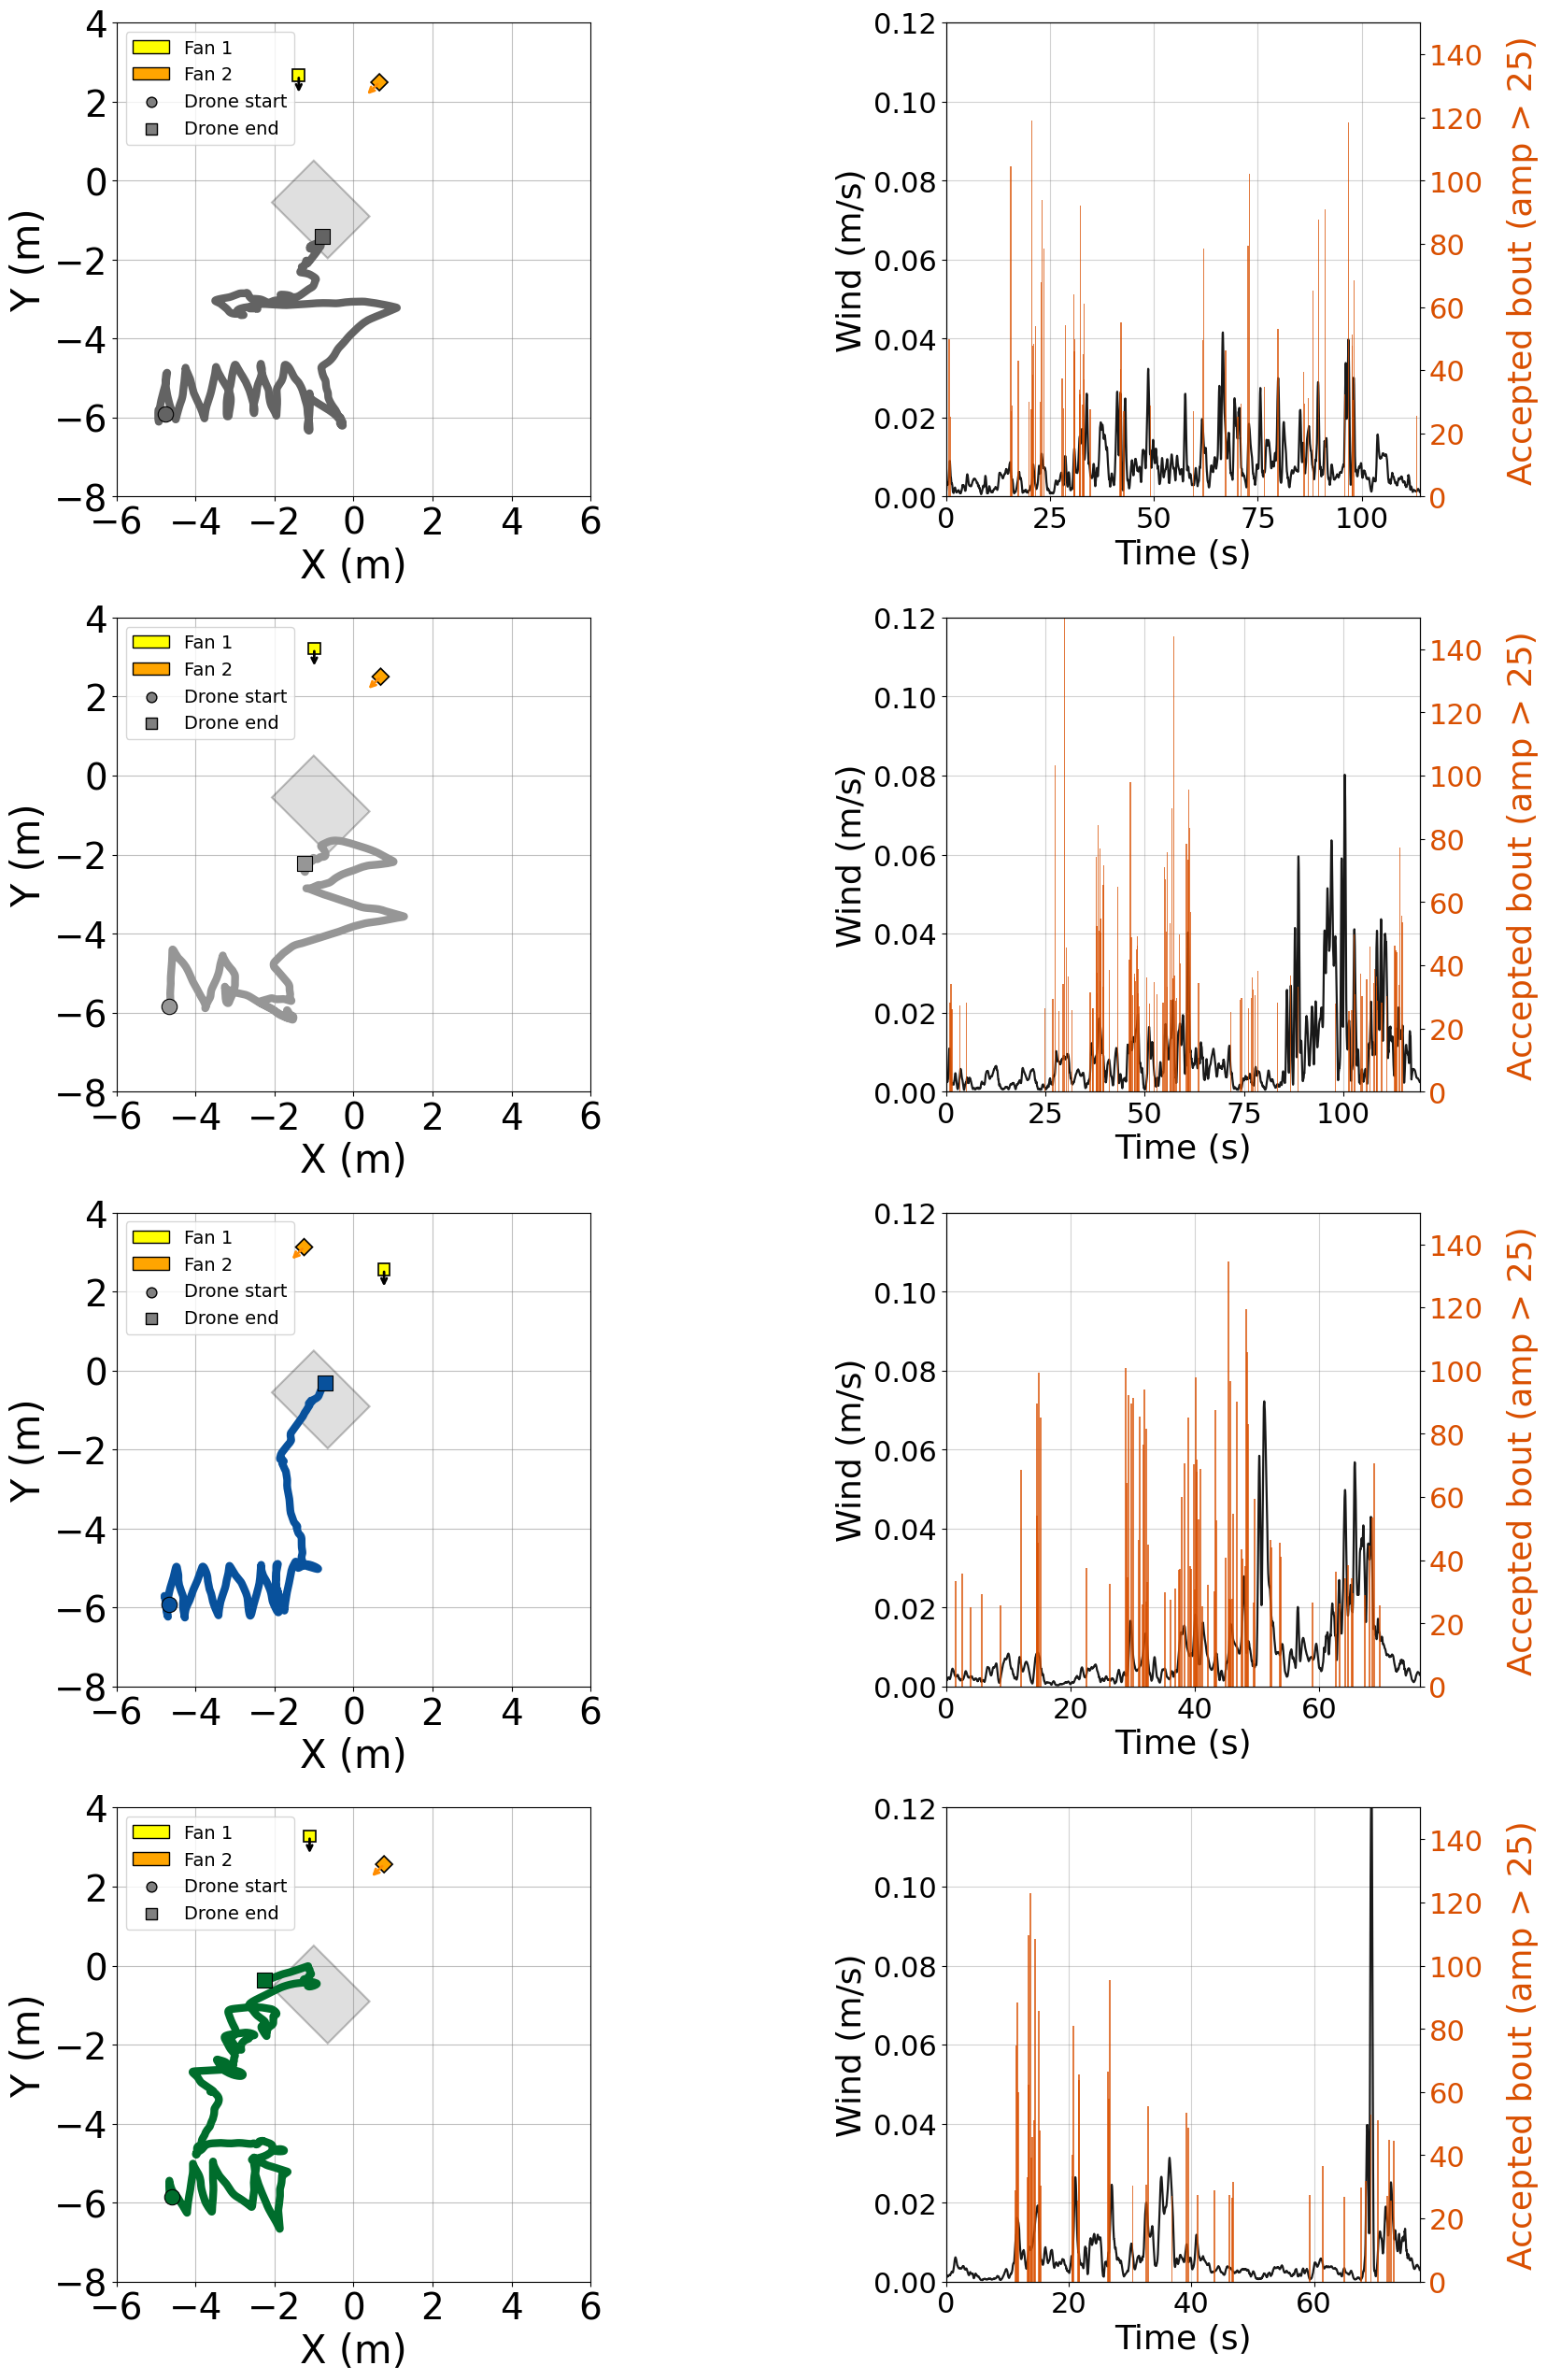

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Polygon
import matplotlib.patches as mpatches

plt.style.use('default')

# ── Trajectory (OptiTrack) files ──────────────────────────────────────────────
TRAJECTORY_FILES = r"""
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\ARR_NC_Shifting_5.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Shifting_3_worked_auto_far.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\Good Runs\ARR_NC_Shifting_2_worked_manual_end.csv
C:\Users\ltjth\Documents\Research\UKF_Data\Optitrack\OSL\ARR_NC_Shifting_miss.csv
"""
# Starting fan location
# ARR_NC_Shifting_5.csv -1.386, 2.665
# ARR_NC_Shifting_3_worked_auto_far.csv -0.994, 3.214
# ARR_NC_Shifting_2_worked_manual_end.csv 0.774, 2.566
# ARR_NC_Shifting_miss.csv -1.111, 3.278

# Ending fan location
# ARR_NC_Shifting_5.csv 0.655, 2.489
# ARR_NC_Shifting_3_worked_auto_far.csv 0.687, 2.504
# ARR_NC_Shifting_2_worked_manual_end.csv -1.251, 3.127
# ARR_NC_Shifting_miss.csv 0.774, 2.566

FAN_POSITIONS = {
    'ARR_NC_Shifting_5.csv':                  ((-1.386, 2.665), ( 0.655, 2.489)),
    'ARR_NC_Shifting_3_worked_auto_far.csv':   ((-0.994, 3.214), ( 0.687, 2.504)),
    'ARR_NC_Shifting_2_worked_manual_end.csv': (( 0.774, 2.566), (-1.251, 3.127)),
    'ARR_NC_Shifting_miss.csv':                ((-1.111, 3.278), ( 0.774, 2.566)),
}

LOG_FILES = [
    r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_NC_Shifting1_miss.csv",
    r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_NC_Shifting5.csv",
    r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_NC_Shifting2_worked_manualend.csv",
    r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_NC_Shifting3_worked_auto_far.csv",
]

COL_TIME     = 'Time'
COL_WIND     = 'Wind'
COL_BOUT_AMP = 'BoutAmp'
BOUT_THRESHOLD = 25

WIND_YLIM = (0, 0.12)
BOUT_YLIM = (0, 150)
RUN_COLORS = ['#636363', '#969696', '#08519c', '#006d2c']
WIND_COLOR = 'black'
BOUT_COLOR = '#d94f00'

FONT_TRAJ = 30
FONT_TS   = 26
TICK_TRAJ = 28
TICK_TS   = 22

FAN_START_ANGLE  = 270
FAN_END_ANGLE    = 135.0

ZONE_WIDTH = 2.0
ZONE_DEPTH = 1.5


# ── Helpers ───────────────────────────────────────────────────────────────────

def find_rigid_body_position_cols(filepath, body_name):
    with open(filepath) as f:
        lines = f.readlines()
    name_line  = lines[3].strip().split(',')
    attr_line  = lines[5].strip().split(',')
    coord_line = lines[6].strip().split(',')
    x_col = y_col = None
    for i, (n, a, c) in enumerate(zip(name_line, attr_line, coord_line)):
        if n.strip() == body_name and a.strip() == 'Position':
            if c.strip() == 'X': x_col = i
            elif c.strip() == 'Y': y_col = i
    return x_col, y_col


def load_optitrack(filepath):
    return pd.read_csv(filepath, skiprows=6, header=0, low_memory=False)


def get_optitrack_origin(filepath):
    """Return last valid Fan position as the world origin for this file."""
    x_col, y_col = find_rigid_body_position_cols(filepath, 'Fan')
    df = load_optitrack(filepath)
    fx = pd.to_numeric(df.iloc[:, x_col], errors='coerce').dropna()
    fy = pd.to_numeric(df.iloc[:, y_col], errors='coerce').dropna()
    return fx.iloc[-1], fy.iloc[-1]


def rotate(points, angle_deg):
    a = np.radians(angle_deg)
    c, s = np.cos(a), np.sin(a)
    R = np.array([[c, -s], [s, c]])
    return points @ R.T


def make_landing_zone(fan_pos, angle_deg, width=ZONE_WIDTH, depth=ZONE_DEPTH):
    half_w = width / 2
    local = np.array([
        [-half_w, 0],
        [ half_w, 0],
        [ half_w, depth],
        [-half_w, depth],
    ])
    world = rotate(local, angle_deg) + np.array(fan_pos)
    return world


def load_log(path):
    try:
        df = pd.read_csv(path, low_memory=False)
        df.columns = df.columns.str.strip()
        return df
    except Exception as e:
        print(f"  [warn] Could not load {path}: {e}")
        return None


def plot_trajectory(ax, filepath, color, origin):
    import os
    ax.set_facecolor('white')

    origin_x, origin_y = origin

    # ── Fan positions from comments, shifted by shared origin ─────────────────
    fname = os.path.basename(filepath)
    fan1_pos, fan2_pos = FAN_POSITIONS[fname]

    # ── Landing zone at fan 2 only ────────────────────────────────────────────
    zone2 = make_landing_zone((-0.3,-0.2), FAN_END_ANGLE)
    ax.add_patch(Polygon(zone2, closed=True, linewidth=1.5,
                         edgecolor='black', facecolor='gray', alpha=0.25, zorder=2))

    # ── Fan markers ───────────────────────────────────────────────────────────
    fan_size = 0.3
    fan_local = np.array([
        [-fan_size/2, -fan_size/2],
        [ fan_size/2, -fan_size/2],
        [ fan_size/2,  fan_size/2],
        [-fan_size/2,  fan_size/2],
    ])

    fan1_world = rotate(fan_local, FAN_START_ANGLE) + np.array(fan1_pos)
    ax.add_patch(Polygon(fan1_world, closed=True, linewidth=1.2,
                         edgecolor='black', facecolor='yellow', zorder=6))

    fan2_world = rotate(fan_local, FAN_END_ANGLE) + np.array(fan2_pos)
    ax.add_patch(Polygon(fan2_world, closed=True, linewidth=1.2,
                         edgecolor='black', facecolor='orange', zorder=6))

    # Heading arrows on each fan
    for pos, angle, col in [(fan1_pos, FAN_START_ANGLE, 'black'),
                             (fan2_pos, 225,             'darkorange')]:
        a = np.radians(angle)
        dx, dy = 0.5 * np.cos(a), 0.5 * np.sin(a)
        ax.annotate('', xy=(pos[0]+dx, pos[1]+dy), xytext=pos,
                    arrowprops=dict(arrowstyle='->', color=col, lw=2.0), zorder=8)

    # ── Drone trajectory ──────────────────────────────────────────────────────
    df = load_optitrack(filepath)
    x_col, y_col = find_rigid_body_position_cols(filepath, 'CFMRL')
    x = pd.to_numeric(df.iloc[:, x_col], errors='coerce')
    y = pd.to_numeric(df.iloc[:, y_col], errors='coerce')
    mask = x.notna() & y.notna()
    x = x[mask].values - origin_x
    y = y[mask].values - origin_y

    ax.plot(x, y, color=color, linewidth=6, zorder=4)
    ax.scatter(x[0],  y[0],  color=color, marker='o', s=140,
               zorder=5, edgecolors='black', linewidths=0.8)
    ax.scatter(x[-1], y[-1], color=color, marker='s', s=140,
               zorder=5, edgecolors='black', linewidths=0.8)

    # ── Axes formatting ───────────────────────────────────────────────────────
    ax.set_xlim(-6, 6)
    ax.set_ylim(-8, 4)
    ax.set_xlabel('X (m)', fontsize=FONT_TRAJ)
    ax.set_ylabel('Y (m)', fontsize=FONT_TRAJ)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.5, color='gray')
    ax.tick_params(labelsize=TICK_TRAJ)

    # ── Legend ────────────────────────────────────────────────────────────────
    handles = [
        mpatches.Patch(facecolor='yellow', edgecolor='black', label='Fan 1'),
        mpatches.Patch(facecolor='orange', edgecolor='black', label='Fan 2'),
        plt.scatter([], [], color='gray', marker='o', s=60,
                    edgecolors='black', label='Drone start'),
        plt.scatter([], [], color='gray', marker='s', s=80,
                    edgecolors='black', label='Drone end'),
    ]
    ax.legend(handles=handles, fontsize=14, loc='upper left')


def plot_timeseries(ax_w, log_path):
    ax_b = ax_w.twinx()
    ax_w.set_facecolor('white')

    df = load_log(log_path)
    if df is None:
        return ax_b

    t = pd.to_numeric(df[COL_TIME], errors='coerce').values
    t = (t - t[0]) * 1e-6

    if COL_WIND in df.columns:
        wind = pd.to_numeric(df[COL_WIND], errors='coerce').values
        ax_w.plot(t, wind, color=WIND_COLOR, linewidth=1.6, alpha=0.9, zorder=3)
        ax_w.set_ylabel('Wind (m/s)', color=WIND_COLOR, fontsize=FONT_TS)
        ax_w.tick_params(axis='y', labelcolor=WIND_COLOR, labelsize=TICK_TS)
        ax_w.set_ylim(WIND_YLIM)
        ax_w.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    if COL_BOUT_AMP in df.columns:
        bout = pd.to_numeric(df[COL_BOUT_AMP], errors='coerce').values
        accepted = bout > BOUT_THRESHOLD
        changes  = np.diff(accepted.astype(int), prepend=0, append=0)
        starts   = np.where(changes ==  1)[0]
        ends     = np.where(changes == -1)[0]
        for s, e in zip(starts, ends):
            peak_amp = np.max(bout[s:e])
            t_s  = t[s]
            t_e  = t[min(e, len(t) - 1)]
            width = max(t_e - t_s, 0.3)
            ax_b.bar(t_s + width / 2, peak_amp, width=width,
                     color=BOUT_COLOR, alpha=0.75, zorder=2, align='center')
        ax_b.set_ylabel(f'Accepted bout (amp > {BOUT_THRESHOLD})',
                        color=BOUT_COLOR, fontsize=FONT_TS, labelpad=18)
        ax_b.tick_params(axis='y', labelcolor=BOUT_COLOR, labelsize=TICK_TS)
        ax_b.set_ylim(BOUT_YLIM)

    ax_w.set_xlabel('Time (s)', fontsize=FONT_TS)
    ax_w.tick_params(axis='x', labelsize=TICK_TS)
    ax_w.grid(True, alpha=0.35, color='gray', zorder=0)
    ax_w.set_xlim(t[0], t[-1])

    return ax_b


# ── Main ──────────────────────────────────────────────────────────────────────
traj_paths = [p.strip() for p in TRAJECTORY_FILES.strip().splitlines() if p.strip()]
n_runs = len(traj_paths)

print("Reading origin from file 0...")
origin = get_optitrack_origin(traj_paths[0])
print(f"  Origin (raw): x={origin[0]:.3f}, y={origin[1]:.3f}")

fig, axes = plt.subplots(
    n_runs, 2,
    figsize=(18, 8 * n_runs),
    facecolor='white',
    gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.75, 'hspace': 0.15}
)

twin_axes = {}

for row, (traj_path, log_path) in enumerate(zip(traj_paths, LOG_FILES)):
    ax_traj = axes[row, 0]
    ax_wind = axes[row, 1]
    color   = RUN_COLORS[row % len(RUN_COLORS)]

    plot_trajectory(ax_traj, traj_path, color, origin)
    ax_bout = plot_timeseries(ax_wind, log_path)
    twin_axes[row] = ax_bout

# ── Post-layout: match timeseries height to trajectory height ─────────────────
fig.canvas.draw()

for row in range(n_runs):
    ax_traj = axes[row, 0]
    ax_wind = axes[row, 1]
    ax_bout = twin_axes[row]

    traj_pos = ax_traj.get_position()
    ts_pos   = ax_wind.get_position()
    new_pos  = [ts_pos.x0, traj_pos.y0, ts_pos.width, traj_pos.height]
    ax_wind.set_position(new_pos)
    ax_bout.set_position(new_pos)

plt.show()

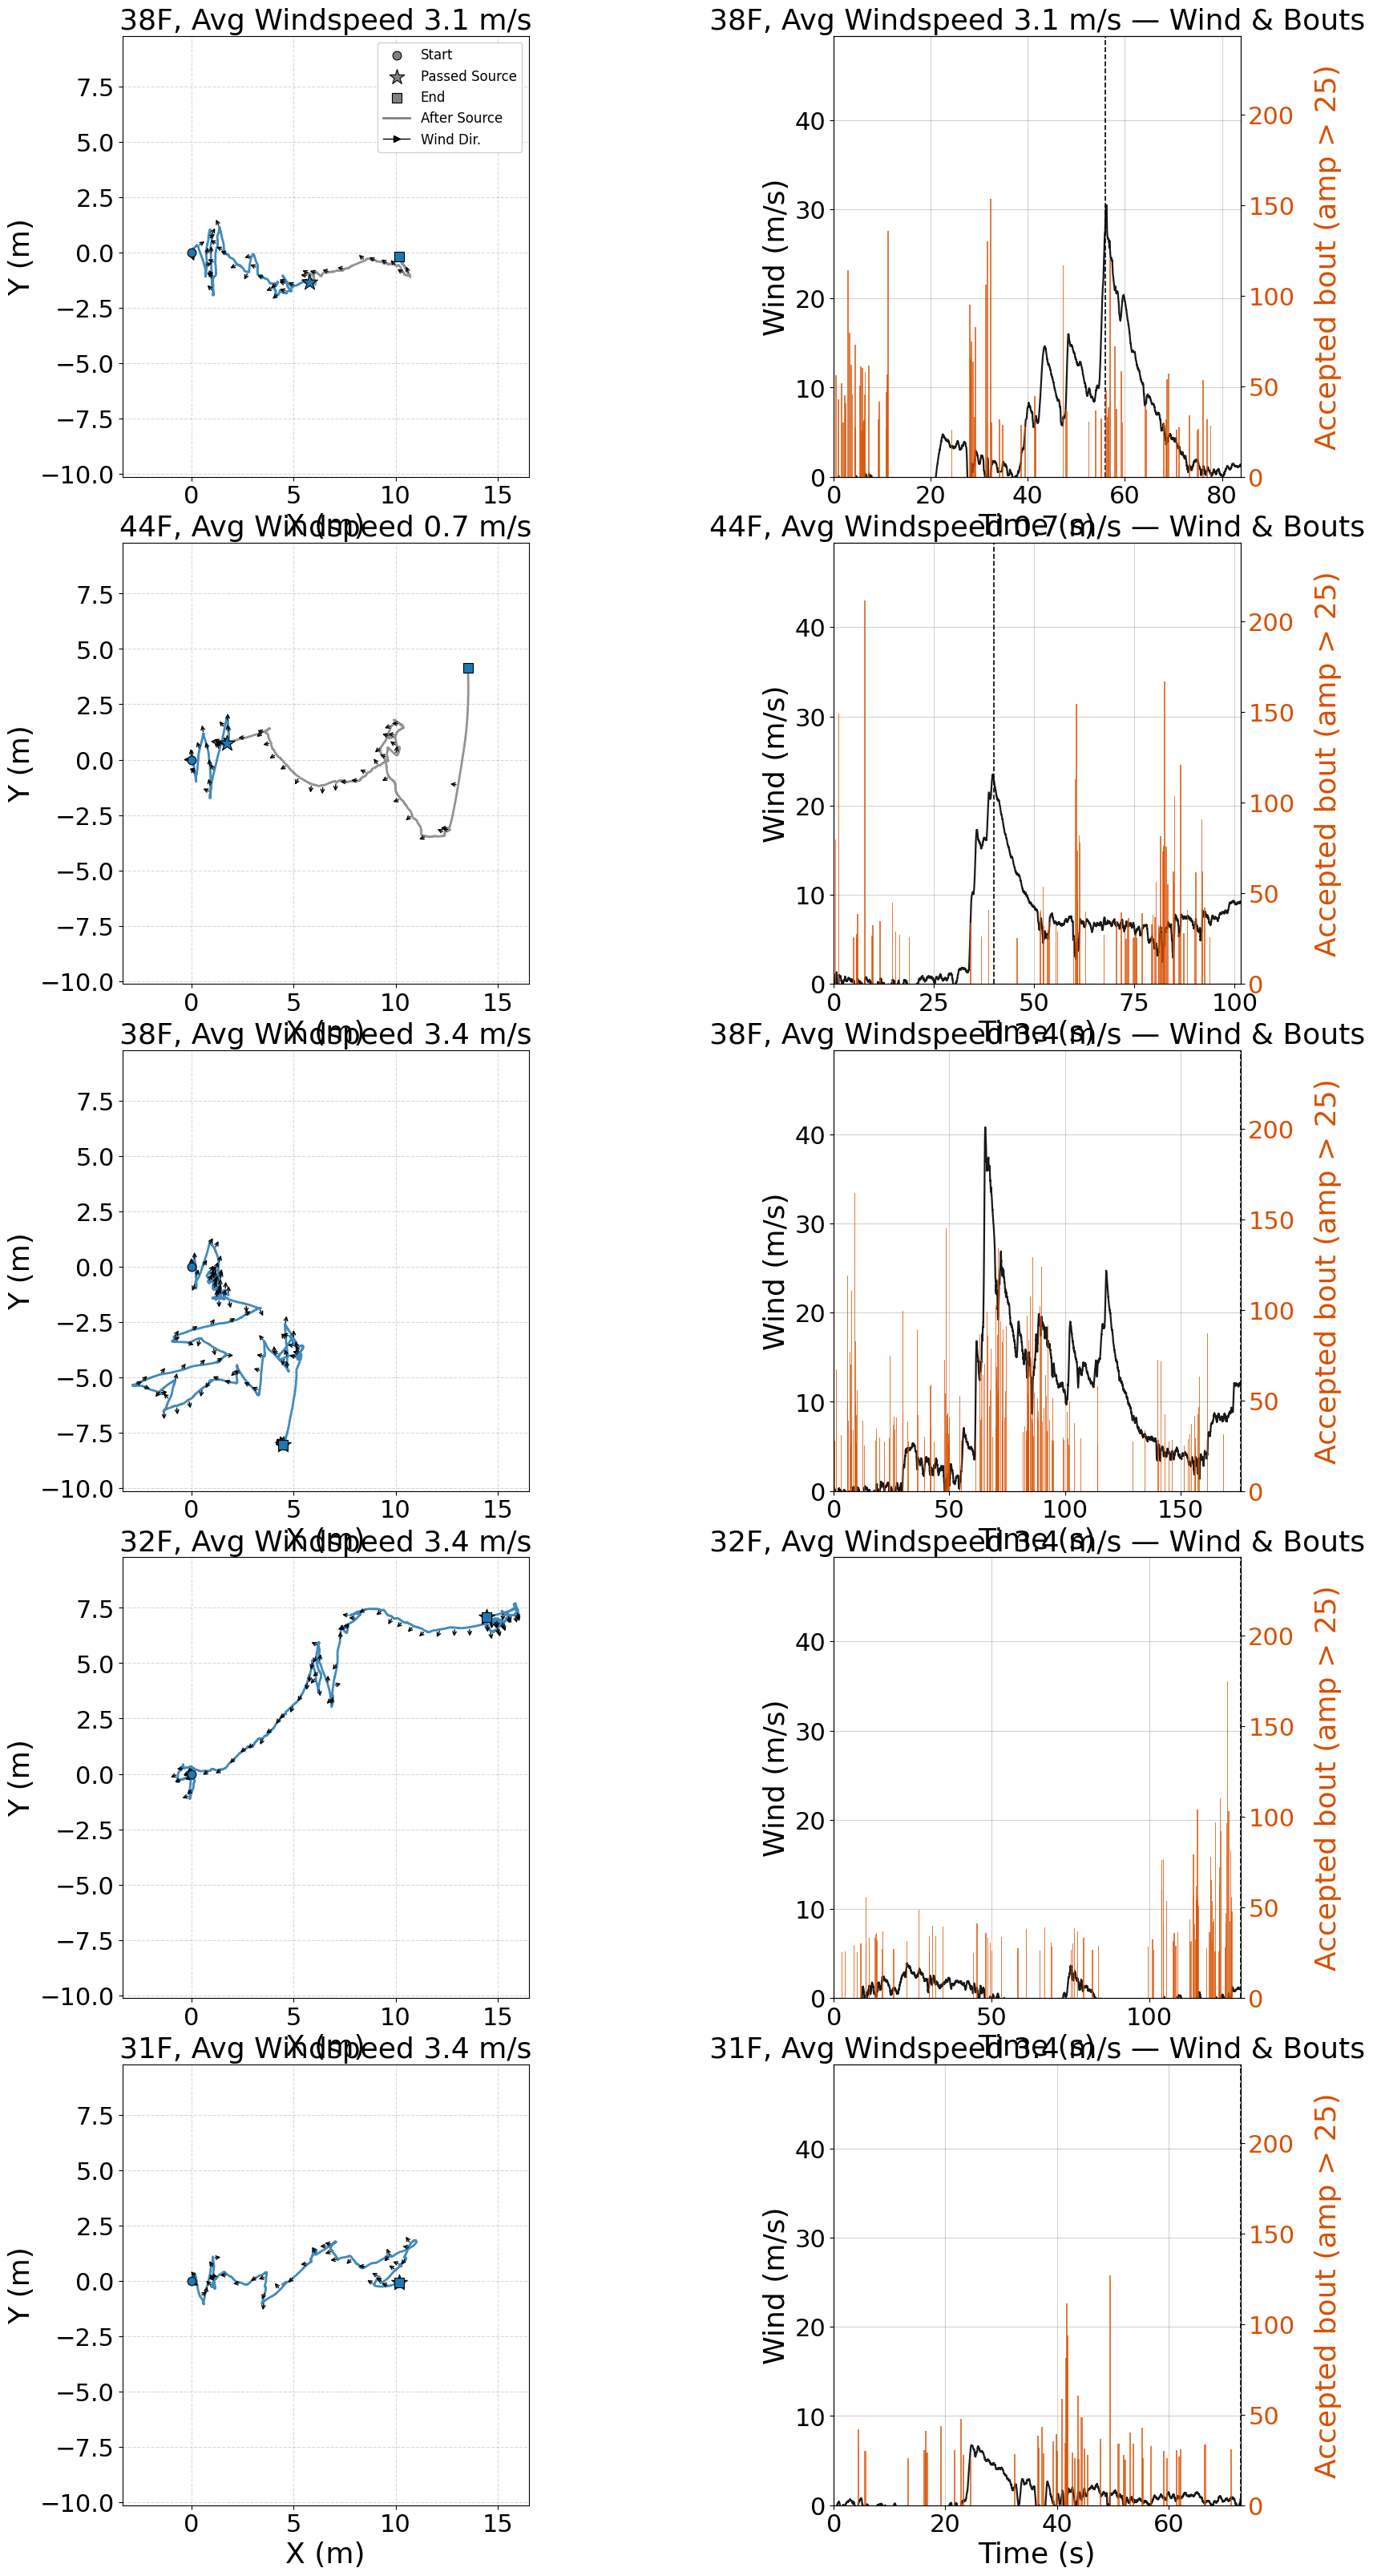

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
plt.style.use('default')

# ─── STYLE (matching indoor code) ────────────────────────────────────────────
FONT_TS   = 26
TICK_TS   = 22
BOUT_COLOR = '#d94f00'
BOUT_THRESHOLD = 25
WIND_COLOR  = 'black'

# ─── FILES & SOURCE PASS INDICES ─────────────────────────────────────────────
files = {
    '38F, Avg Windspeed 3.1 m/s': (r'C:\Users\ltjth\Documents\Research\UKF_Data\ARR_outdoor_38F_alpha1_worked_passed_source.csv', 5600),
    '44F, Avg Windspeed 0.7 m/s': (r'C:\Users\ltjth\Documents\Research\UKF_Data\ARR_outdoor_44F4_initial approach worked_passed_source.csv', 4000),
    '38F, Avg Windspeed 3.4 m/s': (r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_outdoor_38F_alpha_3.4ms1.csv", None),
    '32F, Avg Windspeed 3.4 m/s':(r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_outdoor_38F_beta_1.2ms2.csv", None),
'31F, Avg Windspeed 3.4 m/s':(r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_outdoor_38F_alpha_1.2ms2.csv", None)
}
# ─────────────────────────────────────────────────────────────────────────────

all_x, all_y, all_wind, all_bout = [], [], [], []
for path, _ in files.values():
    df = pd.read_csv(path)
    all_x.append(df['PosX'].values - df['PosX'].values[0])
    all_y.append(df['PosY'].values - df['PosY'].values[0])
    all_wind.append(df['Gas'].values)
    all_bout.append(df['BoutAmp'].values)

x_min = min(x.min() for x in all_x); x_max = max(x.max() for x in all_x)
y_min = min(y.min() for y in all_y); y_max = max(y.max() for y in all_y)
wind_max = max(w.max() for w in all_wind)
bout_max = max(b.max() for b in all_bout)

pad = 0.5
side = max((x_max+pad)-(x_min-pad), (y_max+pad)-(y_min-pad))
x_lim = ((x_min+x_max)/2 - side/2, (x_min+x_max)/2 + side/2)
y_lim = ((y_min+y_max)/2 - side/2, (y_min+y_max)/2 + side/2)

n_runs = len(files)
fig, axes = plt.subplots(n_runs, 2, figsize=(18, 8 * n_runs), facecolor='white',
                         gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.75, 'hspace': 0.15})

twin_axes = {}

for row, (label, (path, split_idx)) in enumerate(files.items()):
    color = 'C0'
    df = pd.read_csv(path)
    x          = df['PosX'].values - df['PosX'].values[0]
    y          = df['PosY'].values - df['PosY'].values[0]
    t_sec      = (df['Time'].values - df['Time'].values[0]) / 1e6
    wind       = df['Gas'].values
    wind       = pd.Series(wind).rolling(window=50, center=True, min_periods=1).mean().values
    bout_amp   = df['BoutAmp'].values
    flow_angle = df['FlowAngle'].values
    n = len(x)
    split_idx = min(split_idx, n - 1) if split_idx is not None else n - 1

    # ── Trajectory ───────────────────────────────────────────────────────────
    ax_traj = axes[row, 0]
    ax_traj.set_facecolor('white')

    ax_traj.plot(x[:split_idx+1], y[:split_idx+1], color=color, linewidth=2, alpha=0.85)
    ax_traj.plot(x[split_idx:],   y[split_idx:],   color='gray', linewidth=2, alpha=0.85)

    ax_traj.scatter(x[0],         y[0],         color=color, marker='o', s=60,  zorder=5, edgecolors='black', linewidths=0.8)
    ax_traj.scatter(x[split_idx], y[split_idx], color=color, marker='*', s=220, zorder=6, edgecolors='black', linewidths=0.8)
    ax_traj.scatter(x[-1],        y[-1],        color=color, marker='s', s=80,  zorder=6, edgecolors='black', linewidths=0.8)

    arrow_len = 0.5
    for i in range(0, len(x), 200):
        angle_rad = np.deg2rad(flow_angle[i]) + np.deg2rad(180)
        dx = np.cos(angle_rad) * arrow_len
        dy = np.sin(angle_rad) * arrow_len
        ax_traj.annotate('',
            xy=(x[i] + dx, y[i] + dy), xytext=(x[i], y[i]),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.0, mutation_scale=8))

    ax_traj.set_xlim(x_lim)
    ax_traj.set_ylim(y_lim)
    ax_traj.set_xlabel('X (m)', fontsize=FONT_TS)
    ax_traj.set_ylabel('Y (m)', fontsize=FONT_TS)
    ax_traj.set_title(label, fontsize=FONT_TS)
    ax_traj.tick_params(labelsize=TICK_TS)
    ax_traj.grid(True, alpha=0.3, linestyle='--', color='gray')

    if row == 0:
        ax_traj.scatter([], [], color='gray', marker='o', s=60,  edgecolors='black', linewidths=0.8, label='Start')
        ax_traj.scatter([], [], color='gray', marker='*', s=200, edgecolors='black', linewidths=0.8, label='Passed Source')
        ax_traj.scatter([], [], color='gray', marker='s', s=80,  edgecolors='black', linewidths=0.8, label='End')
        ax_traj.plot([], [], color='gray', lw=2, label='After Source')
        wind_handle = mlines.Line2D([], [], color='black', marker='>', markersize=6, linewidth=1.0, label='Wind Dir.')
        handles, labels_leg = ax_traj.get_legend_handles_labels()
        ax_traj.legend(handles=handles + [wind_handle], fontsize=12, framealpha=0.9, loc='upper right')

    # ── Timeseries ────────────────────────────────────────────────────────────
    ax_wind = axes[row, 1]
    ax_wind.set_facecolor('white')
    ax_bout_ax = ax_wind.twinx()

    ax_wind.plot(t_sec, wind, color=WIND_COLOR, linewidth=1.6, alpha=0.9, zorder=3)
    ax_wind.set_ylabel('Wind (m/s)', color=WIND_COLOR, fontsize=FONT_TS)
    ax_wind.tick_params(axis='y', labelcolor=WIND_COLOR, labelsize=TICK_TS)
    ax_wind.set_ylim(0, wind_max * 1.15)

    accepted = bout_amp > BOUT_THRESHOLD
    changes  = np.diff(accepted.astype(int), prepend=0, append=0)
    starts   = np.where(changes ==  1)[0]
    ends     = np.where(changes == -1)[0]
    for s, e in zip(starts, ends):
        peak_amp = np.max(bout_amp[s:e])
        t_s  = t_sec[s]
        t_e  = t_sec[min(e, len(t_sec) - 1)]
        width = max(t_e - t_s, 0.3)
        ax_bout_ax.bar(t_s + width / 2, peak_amp, width=width,
                       color=BOUT_COLOR, alpha=0.75, zorder=2, align='center')

    ax_bout_ax.set_ylabel(f'Accepted bout (amp > {BOUT_THRESHOLD})',
                          color=BOUT_COLOR, fontsize=FONT_TS, labelpad=18)
    ax_bout_ax.tick_params(axis='y', labelcolor=BOUT_COLOR, labelsize=TICK_TS)
    ax_bout_ax.set_ylim(0, bout_max * 1.15)

    ax_wind.axvline(t_sec[split_idx], color='black', linestyle='--', linewidth=1.2, label='Passed Source')
    ax_wind.set_xlabel('Time (s)', fontsize=FONT_TS)
    ax_wind.set_title(f'{label} — Wind & Bouts', fontsize=FONT_TS)
    ax_wind.tick_params(axis='x', labelsize=TICK_TS)
    ax_wind.set_xlim(t_sec[0], t_sec[-1])
    ax_wind.grid(True, alpha=0.35, color='gray', zorder=0)

    twin_axes[row] = ax_bout_ax

# ── Post-layout: match timeseries height to trajectory height ─────────────────
fig.canvas.draw()

for row in range(n_runs):
    ax_traj    = axes[row, 0]
    ax_wind    = axes[row, 1]
    ax_bout_ax = twin_axes[row]

    traj_pos = ax_traj.get_position()
    ts_pos   = ax_wind.get_position()
    new_pos  = [ts_pos.x0, traj_pos.y0, ts_pos.width, traj_pos.height]
    ax_wind.set_position(new_pos)
    ax_bout_ax.set_position(new_pos)

plt.show()

In [45]:
####### MOTION COMPOSITE ########

import cv2
import numpy as np

def video_composite(video_path, output_path, every_n_frames=30, threshold=25):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps
    print(f"Video: {total_frames} frames, {fps:.1f} fps, {duration:.1f}s duration")

    start_sec = float(input(f"Start time in seconds (0 to {duration:.1f}): "))
    stop_sec = float(input(f"Stop time in seconds ({start_sec} to {duration:.1f}): "))

    start_frame = int(start_sec * fps)
    stop_frame = int(stop_sec * fps)

    # Seek to start frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    # Read frames in range
    all_frames = []
    for i in range(stop_frame - start_frame):
        ret, frame = cap.read()
        if not ret:
            break
        all_frames.append(frame)
    cap.release()
    print(f"Read {len(all_frames)} frames from {start_sec}s to {stop_sec}s")

    # Compute median background
    print("Computing background...")
    sample = np.array(all_frames[::5])
    background = np.median(sample, axis=0).astype(np.uint8)

    # Select frames to composite
    selected = all_frames[::every_n_frames]
    print(f"Compositing {len(selected)} frames...")

    # Build composite
    composite = background.copy()
    for i, frame in enumerate(selected):
        print(f"  Processing frame {i+1}/{len(selected)}")
        diff = cv2.absdiff(background, frame)
        gray = cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY)
        _, mask = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
        mask = cv2.dilate(mask, np.ones((7, 7), np.uint8), iterations=2)
        composite[mask > 0] = frame[mask > 0]

    cv2.imwrite(output_path, composite)
    print(f"Saved to {output_path}")
#"C:\Users\ltjth\Downloads\ARR_NC_Loc2_UpRedo_run3-Camera 29 (M11498).avi" 92 start 147 end, 50 Hz , 100 frames
video_composite(r"C:\Users\ltjth\Downloads\ARR_NC_Loc2_UpRedo_run3-Camera 29 (M11498).avi", "ARR_fixed.png", every_n_frames=100)

Video: 11394 frames, 50.0 fps, 227.9s duration
Read 2750 frames from 92.0s to 147.0s
Computing background...


MemoryError: Unable to allocate 3.19 GiB for an array with shape (550, 1080, 1920, 3) and data type uint8

Processing data...

--- NO WIND ---
  0.3 ms-1 Line: wind 0.023 ± 0.016 ms-1
  0.3 ms-1 Square: wind 0.081 ± 0.179 ms-1
  0.5 ms-1 Line: wind 0.042 ± 0.026 ms-1
  0.5 ms-1 Square: wind 0.036 ± 0.026 ms-1
  1.0 ms-1 Line: wind 0.035 ± 0.028 ms-1
  1.0 ms-1 Square: wind 0.037 ± 0.029 ms-1
  1.5 ms-1 Line: wind 0.056 ± 0.040 ms-1
  1.5 ms-1 Square: wind 0.050 ± 0.053 ms-1
  2.0 ms-1 Line: wind 0.055 ± 0.077 ms-1
  2.0 ms-1 Square: wind 0.074 ± 0.073 ms-1

--- WITH WIND ---
  0.3 ms-1 Line: wind 0.190 ± 0.280 ms-1
  0.3 ms-1 Square: wind 0.115 ± 0.150 ms-1
  0.5 ms-1 Line: wind 0.106 ± 0.171 ms-1
  0.5 ms-1 Square: wind 0.074 ± 0.127 ms-1
  1.0 ms-1 Line: wind 0.087 ± 0.136 ms-1
  1.0 ms-1 Square: wind 0.085 ± 0.115 ms-1
  1.5 ms-1 Line: wind 0.099 ± 0.169 ms-1
  1.5 ms-1 Square: wind 0.073 ± 0.094 ms-1
  2.0 ms-1 Line: wind 0.095 ± 0.138 ms-1
  2.0 ms-1 Square: wind 0.091 ± 0.098 ms-1

Generating figure...


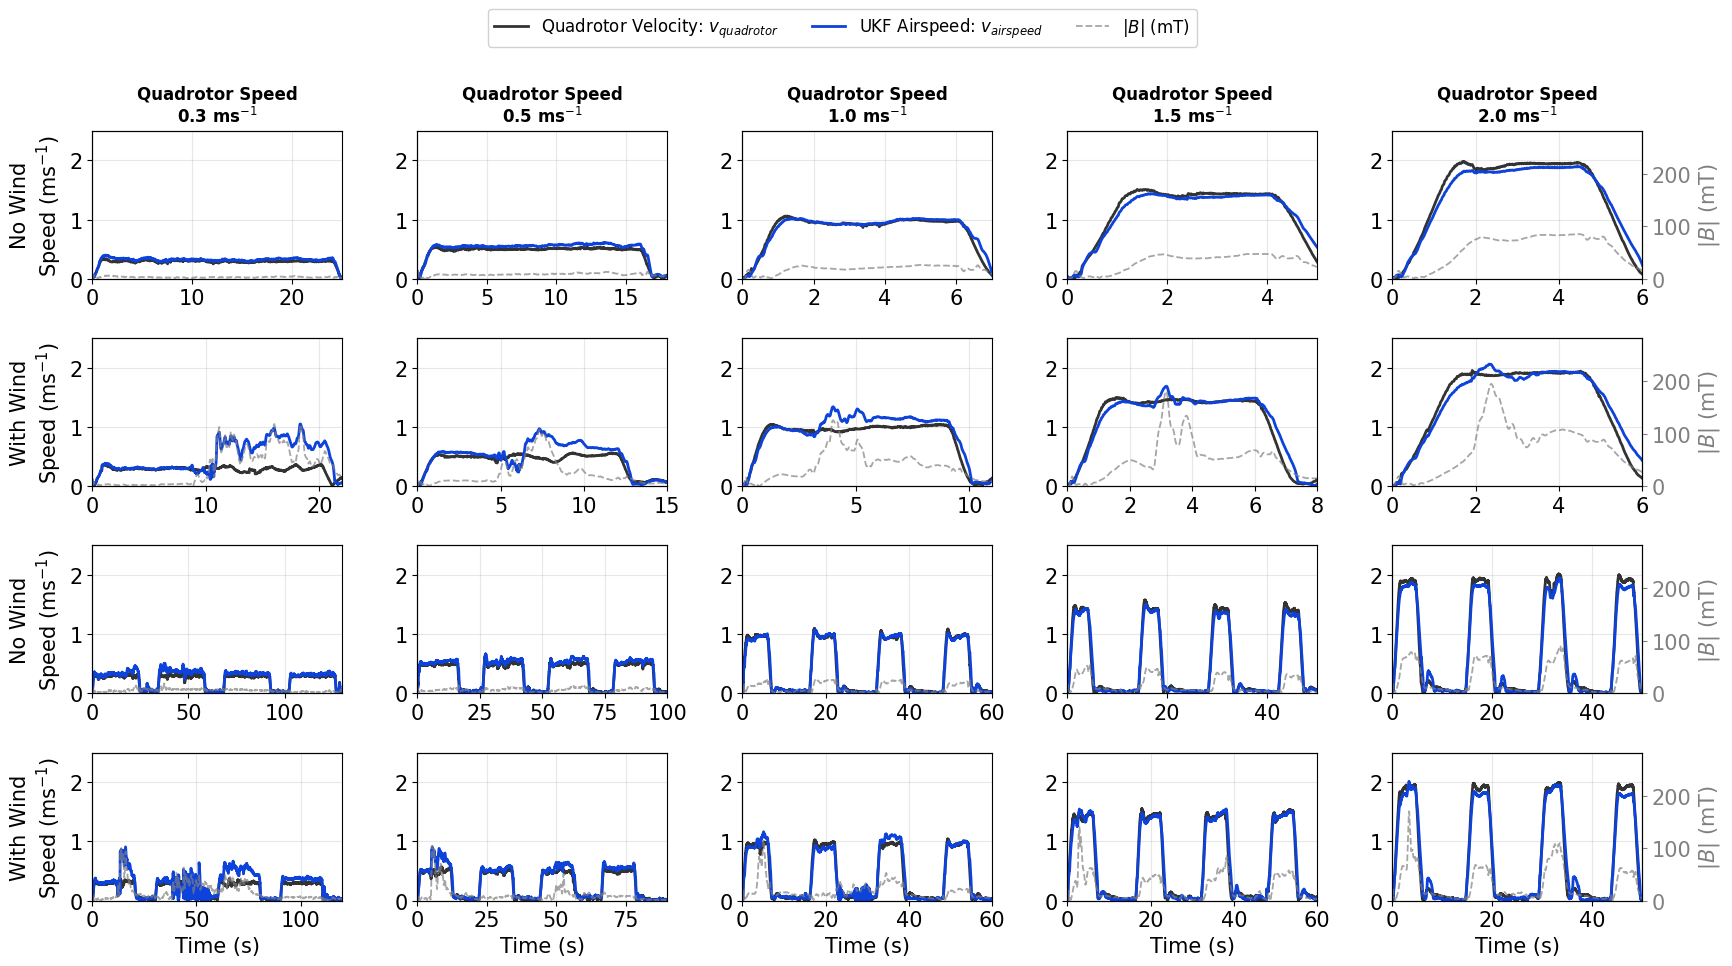

In [36]:
"""
Wind Comparison Analysis - Multi-Speed Comparison
Layout: 4 rows x 5 columns
  Row 0: Line   - No Wind   | cols = speeds
  Row 1: Line   - With Wind
  Row 2: Square - No Wind
  Row 3: Square - With Wind
"""

%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from filterpy.kalman import UnscentedKalmanFilter as UKF
from filterpy.kalman import MerweScaledSigmaPoints
from collections import deque


# =============================================================================
# Data Loading
# =============================================================================

class CausalMovingAverage:
    """Causal (online/live) moving average filter using a fixed-size window."""

    def __init__(self, window=20):
        self.window = window
        self.buffer = deque(maxlen=window)

    def reset(self):
        self.buffer.clear()

    def update(self, value):
        self.buffer.append(value)
        return np.mean(self.buffer)

    def filter_array(self, data):
        """Apply filter sample-by-sample to simulate live processing."""
        self.reset()
        out = np.zeros(len(data))
        for i, v in enumerate(data):
            out[i] = self.update(v)
        return out


def load_data(filepath, ma_window=20):
    """Load flight data CSV and preprocess magnetic field with causal moving average."""
    df = pd.read_csv(filepath)

    ma_x = CausalMovingAverage(window=ma_window)
    ma_y = CausalMovingAverage(window=ma_window)

    df['Bx_filt'] = ma_x.filter_array(df['Bx'].values)
    df['By_filt'] = ma_y.filter_array(df['By'].values)

    df['Bx_cf'] = df['Bx_filt']
    df['By_cf'] = df['By_filt']

    df['B_mag'] = np.sqrt(df['Bx_cf'] ** 2 + df['By_cf'] ** 2)
    df['Bxy_mag'] = df['B_mag']

    if all(col in df.columns for col in ['Qx', 'Qy', 'Qz']):
        qw_sq = 1.0 - (df['Qx'] ** 2 + df['Qy'] ** 2 + df['Qz'] ** 2)
        df['qw'] = np.sqrt(np.maximum(qw_sq, 0))

    if 'Vx' in df.columns:
        df['V_mag'] = np.sqrt(df['Vx'] ** 2 + df['Vy'] ** 2)

    return df


# =============================================================================
# Sensor Model
# =============================================================================

class QuadraticSensorModel:
    def __init__(self):
        self.inv_a = -0.000213
        self.inv_b = 0.03955
        self.inv_c = 0.03621
        self.fwd_a = 29.47
        self.fwd_b = -7.7
        self.fwd_c = 5.44

    def velocity_to_B(self, v_mag):
        B = self.fwd_a * v_mag ** 2 + self.fwd_b * v_mag + self.fwd_c
        return np.maximum(B, 0)

    def B_to_velocity(self, B_mag):
        v = self.inv_a * B_mag ** 2 + self.inv_b * B_mag + self.inv_c
        return np.maximum(v, 0)


# =============================================================================
# Airflow Estimation UKF
# =============================================================================

class AirflowUKF:
    def __init__(self, dt, sensor_model, Q_airflow=0.5, R_magnetic=None, R_odom=0.003):
        self.dt = dt
        self.sensor_model = sensor_model
        self.R_odom = R_odom

        self.dim_x = 2
        self.dim_z = 2

        points = MerweScaledSigmaPoints(n=self.dim_x, alpha=0.1, beta=2.0, kappa=0.0)

        self.ukf = UKF(
            dim_x=self.dim_x,
            dim_z=self.dim_z,
            dt=dt,
            fx=self._fx,
            hx=self._hx,
            points=points
        )

        self.ukf.x = np.zeros(2)
        self.ukf.P = np.eye(2) * 1.0
        self.ukf.Q = np.eye(2) * Q_airflow

        if R_magnetic is not None:
            self.ukf.R = R_magnetic
        else:
            self.ukf.R = np.array([
                [0.72422324, 0.33065],
                [0.33065, 0.76509166]
            ])

    def _fx(self, x, dt):
        return x

    def _hx(self, x):
        va_x, va_y = x
        v_mag = np.sqrt(va_x ** 2 + va_y ** 2)
        c = 29.47
        b = -7.7
        Bx = c * v_mag * va_x + b * va_x
        By = c * v_mag * va_y + b * va_y
        return np.array([Bx, By])

    def predict(self):
        self.ukf.P = 0.5 * (self.ukf.P + self.ukf.P.T)
        self.ukf.P += np.eye(self.dim_x) * 1e-6
        self.ukf.predict()

    def update_with_velocity(self, vx_body, vy_body):
        z = np.array([-vx_body, -vy_body])
        H = np.eye(2)
        R_odom = np.eye(2) * self.R_odom
        y = z - self.ukf.x
        S = H @ self.ukf.P @ H.T + R_odom
        K = self.ukf.P @ H.T @ np.linalg.inv(S)
        self.ukf.x = self.ukf.x + K @ y
        self.ukf.P = (np.eye(2) - K @ H) @ self.ukf.P

    def update(self, Bx, By):
        z = np.array([Bx, By])
        self.ukf.P = 0.5 * (self.ukf.P + self.ukf.P.T)
        self.ukf.P += np.eye(self.dim_x) * 1e-6
        try:
            self.ukf.update(z)
        except np.linalg.LinAlgError:
            self.ukf.P = np.eye(self.dim_x) * 1.0

    @property
    def airflow(self):
        return self.ukf.x.copy()


# =============================================================================
# Run UKF
# =============================================================================

def run_ukf(df, Q_airflow=0.005, R_magnetic=None, R_odom=0.001):
    if 'time' in df.columns:
        time = df['time'].values
        if time[0] > 1000:
            time = time / 1000.0
        dt = np.median(np.diff(time))
    else:
        dt = 0.02
        time = np.arange(len(df)) * dt

    time = time - time[0]

    sensor_model = QuadraticSensorModel()
    ukf = AirflowUKF(dt, sensor_model, Q_airflow=Q_airflow,
                     R_magnetic=R_magnetic, R_odom=R_odom)

    N = len(df)
    results = {
        'time': time,
        'va_x': np.zeros(N),
        'va_y': np.zeros(N),
        'va_mag': np.zeros(N),
        'v_empirical': np.zeros(N),
        'vx_true': df['Vx'].values,
        'vy_true': df['Vy'].values,
        'v_true_mag': np.sqrt(df['Vx'] ** 2 + df['Vy'] ** 2).values,
        'Bx': df['Bx_cf'].values,
        'By': df['By_cf'].values,
        'B_mag': df['B_mag'].values,
        'wind_x': np.zeros(N),
        'wind_y': np.zeros(N),
        'wind_mag': np.zeros(N),
    }

    for i in range(N):
        ukf.predict()

        Bx = df['Bx_cf'].iloc[i]
        By = df['By_cf'].iloc[i]
        ukf.update(Bx, By)
        ukf.update_with_velocity(df['Vx'].iloc[i], df['Vy'].iloc[i])

        va = ukf.airflow
        results['va_x'][i] = va[0]
        results['va_y'][i] = va[1]
        results['va_mag'][i] = np.sqrt(va[0] ** 2 + va[1] ** 2)
        results['v_empirical'][i] = sensor_model.B_to_velocity(df['B_mag'].iloc[i])

        results['wind_x'][i] = va[0] + df['Vx'].iloc[i]
        results['wind_y'][i] = va[1] + df['Vy'].iloc[i]
        results['wind_mag'][i] = np.sqrt(results['wind_x'][i] ** 2 + results['wind_y'][i] ** 2)

    return results


# =============================================================================
# Plotting
# =============================================================================

def compute_B_ylim(results_no_wind, results_wind, speeds, margin=1.1):
    """Compute a consistent y-limit for |B| across all subplots."""
    all_B = []
    for results_dict in [results_no_wind, results_wind]:
        for speed in speeds:
            for traj in ['Line', 'Square']:
                if speed in results_dict and traj in results_dict[speed]:
                    all_B.append(results_dict[speed][traj]['B_mag'])
    if all_B:
        return (0, np.nanmax(np.concatenate(all_B)) * margin)
    return (0, 8)


def plot_comparison(results_no_wind, results_wind, speeds,
                    xlim_line_no_wind, xlim_square_no_wind,
                    xlim_line_wind, xlim_square_wind,
                    title_fontsize=20,
                    label_fontsize=11,
                    tick_fontsize=15):

    n_speeds = len(speeds)
    fig = plt.figure(figsize=(4 * n_speeds, 10))
    gs = fig.add_gridspec(4, n_speeds, hspace=0.4, wspace=0.3)

    ylim_vel = 2.5
    color_odom = '#000000'
    color_ukf  = '#0d42db'
    color_bmag = 'gray'

    # Consistent |B| ylim across all subplots
    B_ylim = compute_B_ylim(results_no_wind, results_wind, speeds)

    rows = [
        ('Line',   'no_wind', xlim_line_no_wind,   'No Wind'),
        ('Line',   'wind',    xlim_line_wind,       'With Wind'),
        ('Square', 'no_wind', xlim_square_no_wind,  'No Wind'),
        ('Square', 'wind',    xlim_square_wind,     'With Wind'),
    ]

    legend_handles = None

    for row_idx, (traj, condition, xlim_dict, row_label) in enumerate(rows):
        for col_idx, speed in enumerate(speeds):
            ax = fig.add_subplot(gs[row_idx, col_idx])

            results_dict = results_no_wind if condition == 'no_wind' else results_wind

            if speed not in results_dict or traj not in results_dict[speed]:
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center',
                        transform=ax.transAxes, fontsize=label_fontsize)
                ax.set_xlim([0, xlim_dict.get(speed, 17)])
                ax.set_ylim([0, ylim_vel])
            else:
                results = results_dict[speed][traj]

                # Left axis — velocity
                l1, = ax.plot(results['time'], results['v_true_mag'],
                              color=color_odom, lw=2,
                              label='Quadrotor Velocity: $v_{quadrotor}$', alpha=0.8)
                l2, = ax.plot(results['time'], results['va_mag'],
                              color=color_ukf, lw=2,
                              label='UKF Airspeed: $\hat{v}_a$')

                ax.set_xlim([0, xlim_dict.get(speed, 17)])
                ax.set_ylim([0, ylim_vel])
                ax.grid(True, alpha=0.3)

                # Right axis — |B|
                ax2 = ax.twinx()
                l3, = ax2.plot(results['time'], results['B_mag'],
                               color=color_bmag, lw=1.3,
                               label='$|B|$ (mT)', alpha=0.7, linestyle='--')

                # Consistent ylim for |B| across all subplots
                ax2.set_ylim(B_ylim)

                # Only show right axis on rightmost column
                if col_idx == n_speeds - 1:
                    ax2.set_ylabel('$|B|$ (mT)', fontsize=label_fontsize, color=color_bmag)
                    ax2.tick_params(axis='y', labelsize=tick_fontsize, colors=color_bmag)
                    ax2.spines['right'].set_visible(True)
                else:
                    ax2.set_yticks([])
                    ax2.spines['right'].set_visible(False)

                if legend_handles is None:
                    legend_handles = [l1, l2, l3]

            ax.tick_params(axis='both', labelsize=tick_fontsize)

            if row_idx == 0:
                ax.set_title(f'Quadrotor Speed\n{speed} ms$^{{-1}}$',
                             fontsize=title_fontsize, fontweight='bold')

            if row_idx == 3:
                ax.set_xlabel('Time (s)', fontsize=label_fontsize)

            if col_idx == 0:
                ax.set_ylabel(f'{row_label}\nSpeed (ms$^{{-1}}$)', fontsize=label_fontsize)

    if legend_handles:
        fig.legend(legend_handles,
                   ['Quadrotor Velocity: $v_{quadrotor}$',
                    'UKF Airspeed: ${v}_{airspeed}$',
                    '$|B|$ (mT)'],
                   loc='upper center', bbox_to_anchor=(0.5, 1.01),
                   ncol=3, fontsize=title_fontsize, framealpha=0.9)

    return fig


# =============================================================================
# Main
# =============================================================================

base_path = r"C:\Users\ltjth\Documents\Research\UKF_Data"

files_wind = {
    0.3: {'Line':   f"{base_path}\\CF_ARR_Line_EKF0.3ms_FAN1.csv",
          'Square': f"{base_path}\\CF_ARR_Square_EKF0.3ms_FAN1.csv"},
    0.5: {'Line':   f"{base_path}\\CF_ARR_Line_EKF0.5ms_FAN1.csv",
          'Square': f"{base_path}\\CF_ARR_Square_EKF0.5ms_FAN_run21.csv"},
    1.0: {'Line':   f"{base_path}\\CF_ARR_Line_EKF1.0ms_4.5m_FAN1.csv",
          'Square': f"{base_path}\\CF_ARR_Square_EKF1.0ms_FAN1.csv"},
    1.5: {'Line':   f"{base_path}\\CF_ARR_Line_EKF1.5ms_4.5m_FAN1.csv",
          'Square': f"{base_path}\\CF_ARR_Square_EKF1.5ms_4.5m_FAN_run21.csv"},
    2.0: {'Line':   f"{base_path}\\CF_ARR_Line_EKF2.0ms_4.5m_FAN1.csv",
          'Square': f"{base_path}\\CF_ARR_Square_EKF2.0ms_4.5m_FAN1.csv"},
}

files_no_wind = {
    0.3: {'Line':   f"{base_path}\\CF_ARR_Line_EKF0.31.csv",
          'Square': f"{base_path}\\CF_ARR_Square_EKF0.3ms1.csv"},
    0.5: {'Line':   f"{base_path}\\CF_ARR_Line_EKF0.53.csv",
          'Square': f"{base_path}\\CF_ARR_Square_EKF0.5ms_lowerheight21.csv"},
    1.0: {'Line':   f"{base_path}\\CF_ARR_Line_EKF1.0ms1.csv",
          'Square': f"{base_path}\\CF_ARR_Square_EKF1.0ms1.csv"},
    1.5: {'Line':   f"{base_path}\\CF_ARR_Line_EKF1.5ms1.csv",
          'Square': f"{base_path}\\CF_ARR_Square_EKF1.5ms1.csv"},
    2.0: {'Line':   f"{base_path}\\CF_ARR_Line_EKF2.0ms_4.5m2.csv",
          'Square': f"{base_path}\\CF_ARR_Square_EKF2.0ms_4.5m1.csv"},
}

speeds = [0.3, 0.5, 1.0, 1.5, 2.0]

xlim_line_no_wind   = {0.3: 25,  0.5: 18,  1.0: 7,  1.5: 5,  2.0: 6}
xlim_square_no_wind = {0.3: 130, 0.5: 100, 1.0: 60, 1.5: 50, 2.0: 50}
xlim_line_wind      = {0.3: 22,  0.5: 15,  1.0: 11, 1.5: 8,  2.0: 6}
xlim_square_wind    = {0.3: 120, 0.5: 90,  1.0: 60, 1.5: 60, 2.0: 50}

# -------------------------------------------------------------------------
# Font size controls
# -------------------------------------------------------------------------
TITLE_FONTSIZE = 12
LABEL_FONTSIZE = 15
TICK_FONTSIZE  = 15

# -------------------------------------------------------------------------
# UKF parameters
# -------------------------------------------------------------------------
Q_airflow  = 0.005
R_odom     = 0.003
R_magnetic = np.array([[0.72422324, 0.33065],
                        [0.33065,   0.76509166]])

print("=" * 60)
print("Processing data...")
print("=" * 60)

results_no_wind = {}
results_wind    = {}

for label, files_dict, results_dict in [
    ('NO WIND',   files_no_wind, results_no_wind),
    ('WITH WIND', files_wind,    results_wind),
]:
    print(f"\n--- {label} ---")
    for speed in speeds:
        results_dict[speed] = {}
        for traj in ['Line', 'Square']:
            filepath = files_dict[speed][traj]
            try:
                df = load_data(filepath, ma_window=20)
                res = run_ukf(df, Q_airflow=Q_airflow,
                              R_magnetic=R_magnetic, R_odom=R_odom)
                results_dict[speed][traj] = res
                print(f"  {speed} ms-1 {traj}: wind {np.mean(res['wind_mag']):.3f} "
                      f"± {np.std(res['wind_mag']):.3f} ms-1")
            except FileNotFoundError:
                print(f"  {speed} ms-1 {traj}: file not found")
            except Exception as e:
                print(f"  {speed} ms-1 {traj}: error - {e}")

print("\nGenerating figure...")
fig = plot_comparison(
    results_no_wind, results_wind, speeds,
    xlim_line_no_wind, xlim_square_no_wind,
    xlim_line_wind, xlim_square_wind,
    title_fontsize=TITLE_FONTSIZE,
    label_fontsize=LABEL_FONTSIZE,
    tick_fontsize=TICK_FONTSIZE,
)

# fig.savefig('wind_comparison.png', dpi=500, bbox_inches='tight')
# fig.savefig('wind_comparison.pdf', bbox_inches='tight')
plt.show()

Primary — accepted bouts: 13
44°F Avg Wind Speed: 1.3 ms$^{-1}$ | 100% Ethanol — accepted bouts: 8
44°F Avg Wind Speed: 2.8 ms$^{-1}$ | 100% Ethanol — accepted bouts: 5
38°F Avg Wind Speed: 0.4 ms$^{-1}$ | 100% Ethanol — accepted bouts: 73
72°F Avg Wind Speed: 0.8 ms$^{-1}$ | 33% Ethanol — accepted bouts: 92


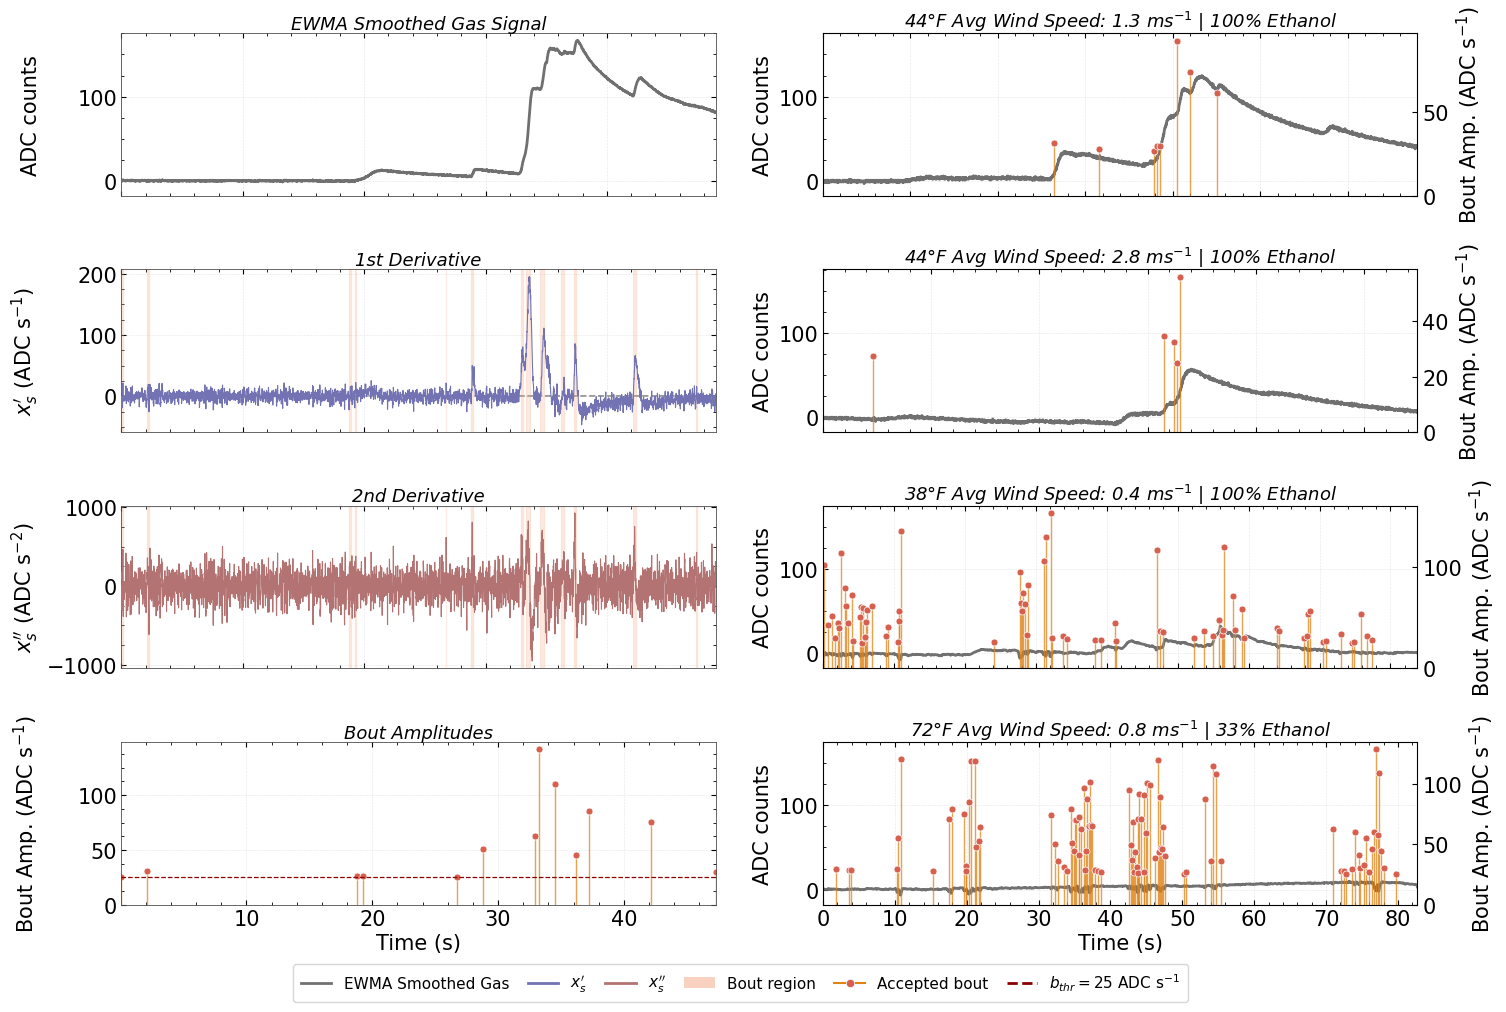

In [44]:
############# BOUT EXPLAINER ###################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib as mpl

mpl.rcParams['font.family']      = 'sans-serif'
mpl.rcParams['font.sans-serif']  = ['DejaVu Sans']
mpl.rcParams['font.size']        = 15
mpl.rcParams['axes.titlesize']   = 12
mpl.rcParams['axes.labelsize']   = 15
mpl.rcParams['xtick.labelsize']  = 15
mpl.rcParams['ytick.labelsize']  = 15
mpl.rcParams['legend.fontsize']  = 15
mpl.rcParams['axes.xmargin'] = 0
# ── Colour palette ────────────────────────────────────────────────────────
C_SIGNAL  = '#707070'
C_BOUT    = '#D6604D'
C_DERIV1  = '#7373B3'
C_SHADE   = '#F4A582'
C_DERIV2  = '#B37373'
C_VLINE_S = '#E08214'
C_THRESH  = '#8B0000'
C_ZERO    = '#888888'

# ── 20-point moving average helper ────────────────────────────────────────
def moving_average(x, n=20):
    kernel = np.ones(n) / n
    return np.convolve(x, kernel, mode='same')

# ── EWMA / bout-detection helper ──────────────────────────────────────────
def run_pipeline(gas, fs=100.0, hl=0.025, ampthresh=25, sd_thr=0.0):
    alpha = 1 - np.exp(-np.log(2) / (hl * fs))
    N = len(gas)
    xs      = np.zeros(N)
    xp_raw  = np.zeros(N)
    xp_s    = np.zeros(N)
    xpp_raw = np.zeros(N)
    xpp_s   = np.zeros(N)

    xs[0] = gas[0]
    for i in range(1, N):
        xs[i] = alpha * gas[i] + (1 - alpha) * xs[i-1]
    for i in range(1, N):
        xp_raw[i] = fs * (xs[i] - xs[i-1])
    xp_s[0] = xp_raw[0]
    for i in range(1, N):
        xp_s[i] = alpha * xp_raw[i] + (1 - alpha) * xp_s[i-1]
    for i in range(1, N):
        xpp_raw[i] = fs * (xp_s[i] - xp_s[i-1])
    xpp_s[0] = xpp_raw[0]
    for i in range(1, N):
        xpp_s[i] = alpha * xpp_raw[i] + (1 - alpha) * xpp_s[i-1]

    bout_regions = []
    in_bout, bout_start, bout_derivs = False, None, []
    for i in range(2, N):
        rising = xpp_s[i] > sd_thr
        if rising and not in_bout:
            in_bout, bout_start, bout_derivs = True, i, [xp_s[i]]
        elif rising and in_bout:
            bout_derivs.append(xp_s[i])
        elif not rising and in_bout:
            in_bout = False
            amp = max(bout_derivs) - min(bout_derivs)
            bout_regions.append({'start': bout_start, 'end': i,
                                  'amp': amp, 'accepted': amp > ampthresh})
            bout_derivs = []

    accepted = [b for b in bout_regions if b['accepted']]
    return xs, xp_s, xpp_s, accepted, alpha

# ── Parameters ────────────────────────────────────────────────────────────
fs        = 100.0
hl        = 0.025
ampthresh = 25
sd_thr    = 0.0

# ── Load primary (pipeline) file ──────────────────────────────────────────
PRIMARY = r"C:\Users\ltjth\Documents\Research\UKF_Data\Outside Data\outdoorBout_manualnotFlying_44F_avg0.41.csv"
df    = pd.read_csv(PRIMARY)
t_raw = (df['Time'] - df['Time'].iloc[0]) * 1e-6
gas   = df['Gas'].values.astype(float)
t     = t_raw.values
xs, xp_s, xpp_s, accepted_bouts, alpha = run_pipeline(gas, fs, hl, ampthresh, sd_thr)
print(f"Primary — accepted bouts: {len(accepted_bouts)}")

# ── Load right-column files ────────────────────────────────────────────────
RC_FILES = [
    r"C:\Users\ltjth\Documents\Research\UKF_Data\Outside Data\outdoorBout_manualnotFlying_44F_avg1.31.csv",
    r"C:\Users\ltjth\Documents\Research\UKF_Data\Outside Data\outdoorBout_manualnotFlying_44F_avg2.81.csv",
    r"C:\Users\ltjth\Documents\Research\UKF_Data\ARR_outdoor_38F_alpha1_worked_passed_source.csv",
    r"C:\Users\ltjth\Documents\Research\UKF_Data\Good Runs\ARR_NC_Loc2_UpRedo3.csv",
]
RC_LABELS = ['44°F Avg Wind Speed: 1.3 ms$^{-1}$ | 100% Ethanol', '44°F Avg Wind Speed: 2.8 ms$^{-1}$ | 100% Ethanol',
             '38°F Avg Wind Speed: 0.4 ms$^{-1}$ | 100% Ethanol', '72°F Avg Wind Speed: 0.8 ms$^{-1}$ | 33% Ethanol']

MAVG_ROWS = {2, 3}
MAVG_N    = 20

rc_data = []
for idx, (path, lbl) in enumerate(zip(RC_FILES, RC_LABELS)):
    d  = pd.read_csv(path)
    tr = (d['Time'] - d['Time'].iloc[0]) * 1e-6
    g  = d['Gas'].values.astype(float)
    xs_rc, _, _, bouts, _ = run_pipeline(g, fs, hl, ampthresh, sd_thr)

    if idx in MAVG_ROWS:
        g_display = moving_average(g, MAVG_N)
        suffix = ''
    else:
        g_display = g
        suffix = ''

    rc_data.append({
        't': tr.values, 'g_display': g_display,
        'bouts': bouts, 'label': lbl, 'mavg': idx in MAVG_ROWS, 'suffix': suffix,
    })
    print(f"{lbl} — accepted bouts: {len(bouts)}")

# ── Shared ADC y-limits across all gas concentration panels ───────────────
all_gas_signals = [xs] + [d['g_display'] for d in rc_data]
adc_ymin = min(sig.min() for sig in all_gas_signals)
adc_ymax = max(sig.max() for sig in all_gas_signals)
adc_pad  = (adc_ymax - adc_ymin) * 0.05
adc_ylim = (adc_ymin - adc_pad, adc_ymax + adc_pad)

# ── Y-axis labels ─────────────────────────────────────────────────────────
YLABELS_L = [
    'ADC counts',
    r"$x^\prime_s$ (ADC s$^{-1}$)",
    r"$x^{\prime\prime}_s$ (ADC s$^{-2}$)",
    r'Bout Amp. (ADC s$^{-1}$)',
]

# ── Figure layout: 4 rows × 2 columns ────────────────────────────────────
# Left col : pipeline walkthrough (EWMA → x' → x'' → bout amps)
# Right col: 4 data files, each with gas + bout stems on twin axis
fig = plt.figure(figsize=(14.4, 10.5))
fig.patch.set_facecolor('white')
gs = GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.18,
              top=0.93, bottom=0.10, left=0.07, right=0.97)

axes_l = [fig.add_subplot(gs[i, 0]) for i in range(4)]
axes_r = [fig.add_subplot(gs[i, 1]) for i in range(4)]

def style_ax(ax, ylabel, last_row):
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)
        spine.set_color('0.3')
    ax.tick_params(which='both', direction='in', top=True, right=True, pad=3)
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(4))
    ax.grid(which='major', linestyle=':', linewidth=0.4, color='0.82', zorder=0)
    ax.set_ylabel(ylabel, labelpad=4)
    if not last_row:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Time (s)', labelpad=3)

# ══════════════════════════════════════════════════════════════════════════
# LEFT COLUMN — pipeline panels
# ══════════════════════════════════════════════════════════════════════════

# Panel 0: EWMA
ax = axes_l[0]
ax.plot(t, xs, color=C_SIGNAL, linewidth=2, zorder=3)
style_ax(ax, YLABELS_L[0], False)
ax.set_ylim(adc_ylim)
ax.set_title('EWMA Smoothed Gas Signal', fontsize=13, pad=3, style='italic')


# Panel 1: First derivative
ax = axes_l[1]
ax.axhline(0, color=C_ZERO, linewidth=1.2, linestyle='--', zorder=1)
ax.plot(t, xp_s, color=C_DERIV1, linewidth=0.8, zorder=3)
added = False
for b in accepted_bouts:
    lbl_str = 'Bout region' if not added else '_'
    added = True
    ax.axvspan(t[b['start']], t[b['end']], alpha=0.22, color=C_SHADE, zorder=2, label=lbl_str)
style_ax(ax, YLABELS_L[1], False)
ax.set_title('1st Derivative', fontsize=13, pad=3, style='italic')

# Panel 2: Second derivative
ax = axes_l[2]
ax.plot(t, xpp_s, color=C_DERIV2, linewidth=0.8, zorder=3)
for b in accepted_bouts:
    ax.axvspan(t[b['start']], t[b['end']], alpha=0.22, color=C_SHADE, zorder=2, label='_')
style_ax(ax, YLABELS_L[2], False)
ax.set_title('2nd Derivative', fontsize=13, pad=3, style='italic')

# Panel 3: Bout amplitudes (with threshold — pipeline explanation)
ax = axes_l[3]
if accepted_bouts:
    bout_t   = np.array([t[b['start']] for b in accepted_bouts])
    bout_amp = np.array([b['amp']      for b in accepted_bouts])
    markerline, stemlines, baseline = ax.stem(
        bout_t, bout_amp, markerfmt='o', basefmt=' ')
    plt.setp(stemlines, color=C_VLINE_S, linewidth=1.0, alpha=0.75)
    markerline.set_markerfacecolor(C_BOUT)
    markerline.set_markeredgecolor('white')
    markerline.set_markeredgewidth(0.5)
    markerline.set_markersize(5)
    ax.axhline(ampthresh, color=C_THRESH, linewidth=0.9, linestyle='--',
               label=rf'$b_{{thr}} = {ampthresh}$ ADC s$^{{-1}}$', zorder=3)
    ax.set_ylim(bottom=0)
style_ax(ax, YLABELS_L[3], True)
ax.set_title('Bout Amplitudes', fontsize=13, pad=3, style='italic')
# ══════════════════════════════════════════════════════════════════════════
# RIGHT COLUMN — gas concentration + bout stems (no threshold)
# ══════════════════════════════════════════════════════════════════════════
for row, (ax, d) in enumerate(zip(axes_r, rc_data)):
    tr     = d['t']
    g_disp = d['g_display']
    bouts  = d['bouts']

    # Gas concentration on primary axis
    ax.plot(tr, g_disp, color=C_SIGNAL, linewidth=2, zorder=3)
    style_ax(ax, 'ADC counts', row == 3)
    ax.set_ylim(adc_ylim)
    ax.set_title(d['label'] + d['suffix'], fontsize=13, pad=3, style='italic')

    # Bout amplitude stems on twin right axis — no threshold line
    ax2 = ax.twinx()
    if bouts:
        bout_t   = np.array([tr[b['start']] for b in bouts])
        bout_amp = np.array([b['amp']        for b in bouts])
        markerline, stemlines, baseline = ax2.stem(
            bout_t, bout_amp, markerfmt='o', basefmt=' ')
        plt.setp(stemlines, color=C_VLINE_S, linewidth=1.0, alpha=0.75)
        markerline.set_markerfacecolor(C_BOUT)
        markerline.set_markeredgecolor('white')
        markerline.set_markeredgewidth(0.5)
        markerline.set_markersize(5)
        ax2.set_ylim(bottom=0)

    ax2.set_ylabel(r'Bout Amp. (ADC s$^{-1}$)', labelpad=4)
    ax2.tick_params(axis='y', direction='in')

# ── Align y-labels ────────────────────────────────────────────────────────
fig.align_ylabels(axes_l)
fig.align_ylabels(axes_r)

# ── Global legend ─────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], color=C_SIGNAL,  linewidth=2,  label='EWMA Smoothed Gas'),
    Line2D([0], [0], color=C_DERIV1,  linewidth=2,  label=r"$x^\prime_s$"),
    Line2D([0], [0], color=C_DERIV2,  linewidth=2,  label=r"$x^{\prime\prime}_s$"),
    Patch(facecolor=C_SHADE, alpha=0.5,                label='Bout region'),
    Line2D([0], [0], color=C_VLINE_S, linewidth=1.5,
           marker='o', markerfacecolor=C_BOUT, markeredgecolor='white',
           markeredgewidth=0.5, markersize=6,           label='Accepted bout'),
    Line2D([0], [0], color=C_THRESH,  linewidth=2,
           linestyle='--',                              label=rf'$b_{{thr}} = {ampthresh}$ ADC s$^{{-1}}$'),
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.0),
    ncol=6,
    fontsize=11,
    frameon=True,
    handlelength=2.0,
    borderpad=0.5,
    columnspacing=1.2,
)

plt.show()